# Trabalho Prático de Mineração de Dados — Fase 2
## Utilização de LLMs e Análise Comparativa com Diretrizes de IA Responsável

**Disciplina:** Mineração de Dados  
**Grupo:** 1

Caio Cordeiro Fabri - 2023027939

Carolina Penido Barcellos - 2024024054

Isadora Silva Drumond - 2024074485

Letícia Ribeiro Miranda - 2021095686

**Dataset:** UCI Online Retail 

**Tarefa de mineração:** Padrões frequentes 


**Data da entrega:** 03/05/2026

---

## Objetivo deste notebook

Este notebook documenta a Fase 2 do Trabalho Prático. O objetivo é usar uma ou mais LLMs como apoio à construção da solução de mineração de dados e comparar duas trilhas de interação:

- **Trilha A — baseline:** interação com a LLM sem explicitar diretrizes de IA responsável;
- **Trilha B — guiada:** interação com a LLM explicitando as diretrizes de IA responsável escolhidas pelo grupo.

O foco não é apenas mostrar prompts e respostas. O grupo deve analisar criticamente se a explicitação das diretrizes levou a diferenças concretas na solução proposta, por exemplo em:

- escolha de algoritmos;
- tratamento dos dados;
- seleção de atributos;
- definição de parâmetros;
- métricas de avaliação;
- interpretabilidade;
- privacidade;
- análise de viés;
- custo computacional;
- qualidade da documentação.

> **Importante:** este notebook é um modelo de estrutura. Ele contém exemplos, placeholders e código genérico. O grupo deve substituir os campos indicados por informações reais do seu dataset, das interações com LLMs e dos experimentos efetivamente realizados.


# Como usar este notebook

Este notebook foi organizado seguindo a estrutura esperada para a Fase 2:

1. **Business Understanding**
2. **Data Understanding & Data Preparation**
3. **Modeling**
4. **Evaluation**
5. **Checklist final**

Ao longo do notebook, os trechos marcados entre colchetes, como `[INSERIR LINK DA CONVERSA]`, devem ser preenchidos pelo grupo.

## Diferença entre exemplo e entrega real

- Células de **exemplo** mostram como organizar a entrega.
- Células com **placeholders** indicam pontos que devem ser preenchidos.
- Células de **código** são genéricas e podem precisar de adaptação ao dataset.
- Nenhum resultado experimental deve ser inventado.
- Toda conclusão empírica deve estar apoiada em uma tabela, gráfico ou execução de código.


# 0. Controle da entrega e rastreabilidade

Esta seção registra informações mínimas para tornar o trabalho rastreável e auditável.

| Item | Valor |
|---|---|
| Nome do dataset | UCI Online Retail  |
| Link público do dataset | https://www.kaggle.com/datasets/jinglv127/uci-online-retail  |
| Número de linhas | 541909  |
| Número de colunas | 8 |
| Tarefa de mineração | Padrões frequentes |
| LLM usada na Trilha A | Gemini Pro |
| LLM usada na Trilha B | Gemini Pro |
| Link da conversa — Trilha A | [INSERIR LINK DA CONVERSA] |
| Link da conversa — Trilha B | [INSERIR LINK DA CONVERSA] |

## Diretrizes de IA responsável escolhidas

| Diretriz | Justificativa da escolha | Como será explicitada na Trilha B |
|---|---|---|
| Explicabilidade | Essencial para que as recomendações de cross-selling sejam acionáveis. Não basta saber que os itens se associam, é preciso que a regra faça sentido lógico para a estratégia de marketing. | O prompt deve conter a cláusula: Considere explicitamente as seguintes diretrizes de IA responsável - Explicabilidade: As regras de associação precisam ser compreensíveis para gerar valor de negócio (ex: entender por que produtos são comprados juntos).|
| Eficiência e Escalabilidade | O volume de transações do varejo online exige algoritmos que minimizem o número de varreduras no banco de dados para evitar gargalos de processamento. | O prompt deve conter a cláusula: Considere explicitamente as seguintes diretrizes de IA responsável - Eficiência e Escalabilidade: O dataset é grande e algoritmos como Apriori podem gerar explosão combinatória, exigindo otimização de tempo e memória.|

> **Propósito pedagógico:** esta seção evita que a análise fique solta ou apenas narrativa. O avaliador precisa conseguir identificar o que foi perguntado à LLM, quando, em qual modelo e com qual objetivo.


In [ ]:
# Configurações iniciais do notebook
# Esta célula centraliza imports e parâmetros gerais.
# O grupo deve adaptar os caminhos, nomes de colunas e tipo de tarefa.

import os
import time
import json
import warnings
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

# Caminho para o dataset.
# Exemplos:
# DATA_PATH = "dados/dataset.csv"
# DATA_PATH = "/content/dataset.csv"
DATA_PATH = "dados/UCI Online Retail.csv"

# Tipo de tarefa do TP.
# Opções sugeridas:
# - "padroes_frequentes"
# - "agrupamento"
# - "classificacao"
TASK_TYPE = "padroes_frequentes"

# Coluna-alvo, se aplicável.
# Para padrões frequentes ou agrupamento, normalmente pode ser None.
TARGET_COLUMN = None  # Exemplo: "classe"

# Coluna ou conjunto de colunas usadas para gerar transações, se o TP for de padrões frequentes.

TRANSACTION_COLUMN = "InvoiceNo" #a cesta será definida por InvoiceNo

print("Configuração carregada.")
print(f"Tarefa definida: {TASK_TYPE}")


Configuração carregada.
Tarefa definida: padroes_frequentes


# 1. Business Understanding

Nesta seção, o grupo deve explicar o problema, o contexto dos dados, a relevância da tarefa e a hipótese experimental sobre o uso das diretrizes de IA responsável.

A seção deve responder:

1. Qual problema será investigado?
2. Por que o dataset é relevante?
3. Qual tarefa de mineração de dados será executada?
4. Qual é o valor esperado da análise?
5. Quais diretrizes de IA responsável foram escolhidas?
6. Por que essas diretrizes são pertinentes ao problema?
7. O que se espera que mude quando essas diretrizes são explicitadas à LLM?


## 1.1 Descrição do problema de negócio

O presente projeto está inserido no contexto de um varejo online com atuação internacional, baseado no Reino Unido, que comercializa uma ampla variedade de produtos para diferentes perfis de clientes. A empresa possui um grande volume de dados transacionais históricos, contendo informações detalhadas sobre compras realizadas ao longo do tempo.

Apesar da disponibilidade desses dados, a organização enfrenta dificuldades em extrair insights estratégicos de forma eficiente, especialmente no que diz respeito à identificação de padrões de consumo. Em particular, torna-se inviável analisar manualmente uma base com mais de meio milhão de registros para descobrir quais produtos são frequentemente adquiridos em conjunto.  

Diante desse cenário, o problema de negócio consiste em transformar dados brutos de transações em conhecimento acionável que permita compreender o comportamento de compra dos clientes. Para isso, será aplicada a técnica de Análise de Cesta de Compras (Market Basket Analysis), com foco na Mineração de Padrões Frequentes e na geração de Regras de Associação, visando identificar relações relevantes entre produtos.

Essas informações são fundamentais para apoiar decisões estratégicas e operacionais, como a recomendação automática de produtos, a definição de promoções combinadas (cross-selling), a organização de catálogos e a otimização da gestão de estoque.

- **Contexto:** Varejo online baseado no Reino Unido, com transações internacionais e um catálogo diversificado de produtos.
- **Problema:** Dificuldade em identificar manualmente quais produtos são frequentemente comprados juntos em uma base de dados com mais de meio milhão de registros.
- **Possíveis interessados:** Gestores de marketing, analistas de e-commerce, gerentes de estoque e desenvolvedores de sistemas de recomendação.
- **Decisões apoiadas pela análise:** Criação de recomendações de produtos baseadas em afinidade de compra, 
desenvolvimento de estratégias de cross-selling, 
organização de vitrines e páginas de produtos no site e 
planejamento de campanhas promocionais com base em combinações frequentes de itens.
- **Limitações iniciais conhecidas:** 
    1. Presença de transações canceladas (identificadas pelo prefixo “C”), que precisam ser tratadas ou removidas.
    2. Valores ausentes em identificadores de clientes e descrições de produtos.
    3. Possível existência de dados inconsistentes ou ruídos (ex.: quantidades negativas ou descrições duplicadas).
    4. Alto custo computacional associado à geração de itemsets frequentes em bases densas, exigindo técnicas eficientes de mineração (como Apriori ou FP-Growth).


## 1.2 Objetivo do dataset, origem e características gerais

### Objetivo do dataset

O propósito do dataset é fornecer um histórico detalhado de transações reais de uma empresa de varejo online para permitir a análise de padrões de compra e comportamento dos clientes. No contexto deste projeto, o objetivo específico é servir de base para a Análise de Cesta de Compras (Market Basket Analysis), visando identificar afinidades entre produtos.

### Origem dos dados

Os dados são originários de uma empresa de varejo online sediada no Reino Unido e estão disponíveis publicamente na plataforma Kaggle.  

Link público: https://www.kaggle.com/datasets/jinglv127/uci-online-retail

### Características do dataset

| Coluna | Tipo esperado | Descrição | Relevância para a tarefa |
|---|---|---|---|
| InvoiceNo | Nominal | Identificador único da transação. | Altíssima: Identifica uma transação. É essencial para agrupar produtos que foram comprados na mesma "cesta" ou transação. |
| StockCode | Nominal | Código identificador do produto. | Altíssima: Utilizado como o identificador único do item para gerar os itemsets frequentes. |
| Description | Nominal | Nome ou descrição do produto | Alta: Importante para a interpretabilidade e explicabilidade dos resultados (saber quais produtos compõem as regras), permitindo traduzir códigos técnicos em nomes compreensíveis para o negócio. |
| Quantity | Inteiro | Quantidade de itens comprados. | Média: Importante para o pré-processamento (remoção de cancelamentos com valores negativos). |
| Country | Nominal | País onde ocorreu a transação. | Média: Pode ser utilizada para filtragens e análises regionais, mitigando riscos de generalização excessiva. |
| InvoiceDate | Datetime | Data e horário exatos em que a compra foi realizada. | Média: Permite análises temporais ou sazonais de padrões de compra, mas isso está fora do escopo projeto |
| UnitPrice | Numérico | Preço unitário do produto em libras esterlinas. | Baixa: Pouco usada na mineração de regras, mas útil para filtrar itens de valor irrelevante. |
| CustomerID | Numérico | Identificador único do cliente que realizou a compra. | Média: Permite analisar a recorrência de padrões de compra por perfil de cliente. |

### Relação com o problema de negócio

Este dataset mostra-se altamente adequado ao problema proposto, pois apresenta a granularidade necessária para a realização da Análise de Cesta de Compras (Market Basket Analysis). A combinação dos atributos InvoiceNo e StockCode permite reconstruir com precisão o contexto de compras simultâneas, possibilitando a identificação de conjuntos de itens adquiridos em uma mesma transação.

Adicionalmente, o atributo Description desempenha um papel essencial ao contribuir para a interpretabilidade dos resultados, alinhando-se a princípios de IA Responsável, especialmente no que se refere à explicabilidade. Dessa forma, as regras de associação geradas não apenas capturam padrões relevantes, mas também permanecem compreensíveis e acionáveis para os tomadores de decisão, facilitando sua aplicação no contexto real do negócio.

Sob a perspectiva de eficiência e escalabilidade, o dataset é adequado por já estar organizado em formato transacional, o que facilita sua utilização direta nos algoritmos de mineração de padrões. Ainda que o volume de dados seja elevado, é possível trabalhar de forma eficiente ao aplicar técnicas como filtragem de itens pouco frequentes e limitação do tamanho dos conjuntos analisados, reduzindo o custo computacional.

Além disso, a escolha de algoritmos mais eficientes, como o FP-Growth, permite evitar a geração excessiva de combinações, tornando o processamento mais rápido mesmo com bases maiores. Dessa forma, o projeto consegue lidar com o tamanho do dataset sem comprometer a viabilidade da análise, garantindo resultados relevantes com um custo computacional controlado.

## 1.3 Diretrizes selecionadas e hipótese experimental

### Diretrizes selecionadas

| Diretriz | Por que é pertinente ao problema? | Possível efeito esperado na solução da LLM |
|---|---|---|
| Explicabilidade | Essencial para que os insights de negócio sejam compreendidos e validados por analistas humanos. O dataset contém milhares de produtos identificados por códigos técnicos; sem tradução clara, as regras geradas são inúteis para o negócio. | A LLM deve priorizar a filtragem de regras triviais ou redundantes (como variações de cor do mesmo item) e focar em associações com Lift > 1.5 que revelem comportamentos não óbvios. Além disso, espera-se o uso de visualizações (matrizes de calor ou grafos) para que um analista humano valide os resultados sem inspecionar logs manuais. |
| Eficiência e Escalabilidade | Necessária devido ao volume de dados, que pode causar "explosão combinatória" em algoritmos menos otimizados. Com 541.909 registros, o uso de algoritmos clássicos como o Apriori pode causar estouro de memória RAM e lentidão excessiva | Ao explicitar esta diretriz, espera-se que a LLM sugira a implementação do algoritmo FP-Growth, que é superior para este volume de dados por evitar a geração explícita de candidatos. Também deve haver a sugestão de técnicas como o uso de matrizes esparsas para otimizar o processamento do one-hot encoding. |

### Hipótese experimental

Esperamos que, ao explicitar as diretrizes de Explicabilidade e Eficiência/Escalabilidade, a LLM proponha uma solução com menor custo computacional (através do algoritmo FP-Growth e matrizes esparsas) e maior interpretabilidade (focando em regras de alto Lift e sem redundâncias), em comparação com a solução baseline que tende a sugerir abordagens tradicionais e menos otimizadas.


### Evidências que serão analisadas

Para avaliar a hipótese, compararemos as trilhas quanto a:

- algoritmos sugeridos;
- etapas de preparação dos dados;
- parâmetros recomendados;
- métricas propostas;
- justificativas técnicas;
- riscos apontados;
- limitações reconhecidas;
- aderência às diretrizes escolhidas.


## 1.4 Interações com LLM — Business Understanding

### Trilha A — baseline

**Modelo utilizado:** Gemini Pro

**Data de acesso:** 01/05/2026

**Link da conversa:** 

**Subtarefa:** obter apoio para formular o Business Understanding.

#### Prompt principal — baseline

"Estou desenvolvendo um trabalho de Mineração de Dados utilizando o dataset "UCI Online Retail", que contém registros de transações de uma loja de varejo online.

A tarefa principal do projeto é realizar uma análise de cesta de compras (Market Basket Analysis), com o objetivo de identificar padrões de produtos frequentemente comprados juntos e gerar regras de associação.

Com base nisso, me ajude a elaborar a etapa de Business Understanding, incluindo:

- O objetivo do uso desse dataset no contexto do problema;
- A origem dos dados e o que eles representam;
- As principais características do conjunto de dados;
- A relação entre os dados e o problema de negócio que se deseja resolver.

Escreva a resposta de forma clara e estruturada."

#### Síntese da resposta da LLM

O Business Understanding define o objetivo do projeto alinhado ao negócio. Neste caso, o uso do dataset visa identificar padrões de produtos comprados juntos (Market Basket Analysis), permitindo melhorar vendas por meio de recomendações, promoções e estratégias de cross-selling.

Os dados vêm de uma loja online do Reino Unido (UCI Online Retail) e representam transações reais entre 2010 e 2011, incluindo produtos, quantidades, clientes e datas. O dataset é grande (mais de 500 mil registros) e tem estrutura transacional, ideal para esse tipo de análise.

As principais variáveis são InvoiceNo (define a cesta), StockCode/Description (itens) e Quantity. No entanto, há problemas de qualidade, como valores nulos, cancelamentos e inconsistências, exigindo pré-processamento.

A relação com o problema de negócio ocorre ao agrupar produtos por transação, permitindo aplicar algoritmos de associação (como Apriori ou FP-Growth) e gerar métricas como suporte, confiança e lift, que indicam quais combinações de produtos têm valor estratégico para recomendações e aumento de vendas.

---

### Trilha B — guiada por diretrizes

**Modelo utilizado:** Gemini Pro  
**Data de acesso:** 02/05/2026  
**Link da conversa:** https://gemini.google.com/share/8ce392fb373a  
**Subtarefa:** obter apoio para formular o Business Understanding considerando as diretrizes escolhidas.

#### Prompt principal — guiado

```text
Estou desenvolvendo um trabalho de Mineração de Dados utilizando o dataset "UCI Online Retail", que contém registros de transações de uma loja de varejo online.

A tarefa principal do projeto é realizar uma análise de cesta de compras (Market Basket Analysis), com o objetivo de identificar padrões de produtos frequentemente comprados juntos e gerar regras de associação.

Com base nisso, me ajude a elaborar a etapa de Business Understanding, incluindo:

- O objetivo do uso desse dataset no contexto do problema;
- A origem dos dados e o que eles representam;
- As principais características do conjunto de dados;
- A relação entre os dados e o problema de negócio que se deseja resolver.

Considere explicitamente as seguintes diretrizes de IA responsável:
Explicabilidade: As regras de associação precisam ser compreensíveis para gerar valor de negócio (ex: entender por que produtos são comprados juntos).
Eficiência e Escalabilidade: O dataset é grande e algoritmos como Apriori podem gerar explosão combinatória, exigindo otimização de tempo e memória.

Além da descrição do problema, indique riscos, limitações e critérios que deveriam orientar a solução de mineração de dados.
```

#### Síntese da resposta da LLM

O dataset UCI Online Retail é utilizado para realizar Análise de Cesta de Compras, com o objetivo de identificar produtos frequentemente comprados juntos e transformar esses padrões em estratégias de negócio, como recomendações de produtos, promoções combinadas e melhoria do layout do e-commerce.

Os dados representam transações reais de uma loja online do Reino Unido entre 2010 e 2011, totalizando mais de 541 mil registros com informações sobre compras, produtos, clientes, preços e países. Contudo, a base possui ruídos operacionais, como cancelamentos, devoluções, valores ausentes e preços zerados, exigindo pré-processamento cuidadoso.

A relação com o problema de negócio ocorre ao agrupar produtos (StockCode) por número de fatura (InvoiceNo), formando “cestas de compra”, que permitem aplicar algoritmos de mineração de dados para descobrir associações entre itens.

As principais diretrizes de IA responsável aplicadas são explicabilidade e eficiência computacional. A explicabilidade garante que as regras encontradas sejam claras, úteis e acionáveis para equipes de negócio. Já a eficiência é essencial devido ao grande volume de dados, favorecendo algoritmos mais escaláveis, como o FP-Growth, em vez do Apriori tradicional.

Entre os riscos do projeto estão sazonalidade dos dados, influência de atacadistas no comportamento de compra e associações falsas causadas por dados inconsistentes. O sucesso da solução depende de bom desempenho técnico, geração de regras relevantes (com Lift > 1) e entrega de recomendações práticas para o negócio.


## 1.5 Análise crítica das trilhas — Business Understanding

| Critério | Trilha A — baseline | Trilha B — guiada | Diferença observada |
|---|---|---|---|
| Clareza do problema | O problema está bem descrito (Market Basket Analysis, recomendações, comportamento do cliente), mas de forma geral e descritiva | [ANALISAR] | [COMPARAR] |
| Relação com o dataset | Explica bem a origem, atributos e uso dos dados; conexão correta com transações e cestas | [ANALISAR] | [COMPARAR] |
| Consideração das diretrizes | Não menciona eficiência, escalabilidade ou explicabilidade explicitamente | [ANALISAR] | [COMPARAR] |
| Identificação de riscos | Menciona apenas limpeza de dados (cancelamentos/devoluções) | [ANALISAR] | [COMPARAR] |
| Qualidade da justificativa | Boa, mas mais descritiva (explica o que fazer e por quê em nível de negócio) | [ANALISAR] | [COMPARAR] |
| Erros ou omissões | Não tem erros graves, mas não fala de escalabilidade e nem discute profundamente a escolha dos algoritmos| [ANALISAR] | [COMPARAR] |

### Síntese crítica

[INSERIR ANÁLISE COMPARATIVA]

A resposta guiada deve ser considerada melhor apenas se houver evidência concreta de melhoria. Exemplos de evidência:

- mencionou atributos sensíveis que a baseline ignorou;
- propôs critérios de avaliação mais adequados;
- apontou limitações metodológicas relevantes;
- sugeriu documentação mais rastreável;
- evitou recomendações inadequadas feitas na baseline.

Caso não haja diferença relevante, isso também deve ser relatado.


# 2. Data Understanding & Data Preparation

Nesta seção, o grupo deve explorar o dataset, identificar problemas de qualidade dos dados e preparar os dados para a etapa de modelagem.

Além disso, deve registrar como a LLM foi usada para apoiar:

- exploração inicial;
- identificação de problemas;
- tratamento de valores ausentes;
- transformação de atributos;
- seleção de variáveis;
- preparação específica para a tarefa de mineração;
- identificação de aspectos relacionados às diretrizes de IA responsável.


In [ ]:
# Carregamento do dataset
# Esta célula deve ser adaptada de acordo com o formato do arquivo.

def carregar_dataset(caminho: str) -> pd.DataFrame:
    # Carrega um dataset a partir de um arquivo CSV, Excel, JSON ou Parquet.
    # Adapte esta função se o dataset estiver em outro formato.
    if caminho == "[INSERIR_CAMINHO_DO_ARQUIVO]":
        raise ValueError("Substitua DATA_PATH pelo caminho real do dataset.")

    caminho_path = Path(caminho)

    if not caminho_path.exists():
        raise FileNotFoundError(f"Arquivo não encontrado: {caminho}")

    if caminho_path.suffix.lower() == ".csv":
        return pd.read_csv(caminho_path)
    elif caminho_path.suffix.lower() in [".xlsx", ".xls"]:
        return pd.read_excel(caminho_path)
    elif caminho_path.suffix.lower() == ".json":
        return pd.read_json(caminho_path)
    elif caminho_path.suffix.lower() == ".parquet":
        return pd.read_parquet(caminho_path)
    else:
        raise ValueError("Formato não tratado neste modelo. Adapte a função carregar_dataset.")

# Exemplo de uso:
# df = carregar_dataset(DATA_PATH)
# print("Dataset carregado com sucesso.")
# print(f"Número de linhas: {df.shape[0]}")
# print(f"Número de colunas: {df.shape[1]}")
# display(df.head())


In [ ]:
df = carregar_dataset(DATA_PATH)
print("Dataset carregado com sucesso.")
print(f"Número de linhas: {df.shape[0]}")
print(f"Número de colunas: {df.shape[1]}")
display(df.head())

Dataset carregado com sucesso.
Número de linhas: 541909
Número de colunas: 8


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01/12/2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01/12/2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01/12/2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01/12/2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01/12/2010 08:26,3.39,17850.0,United Kingdom


In [ ]:
# Verificação mínima das restrições do dataset
# A especificação exige dataset público, com pelo menos 1000 linhas e 4 colunas.
# O link público deve ser documentado em Markdown; aqui validamos apenas dimensões.

def verificar_restricoes_dataset(df: pd.DataFrame) -> None:
    n_linhas, n_colunas = df.shape

    print("Verificação das dimensões do dataset")
    print(f"- Linhas: {n_linhas}")
    print(f"- Colunas: {n_colunas}")

    if n_linhas < 1000:
        print("ATENÇÃO: o dataset possui menos de 1000 linhas.")
    else:
        print("OK: o dataset possui pelo menos 1000 linhas.")

    if n_colunas < 4:
        print("ATENÇÃO: o dataset possui menos de 4 colunas.")
    else:
        print("OK: o dataset possui pelo menos 4 colunas.")

# Executar após carregar o dataset:
# verificar_restricoes_dataset(df)


In [ ]:
verificar_restricoes_dataset(df)

Verificação das dimensões do dataset
- Linhas: 541909
- Colunas: 8
OK: o dataset possui pelo menos 1000 linhas.
OK: o dataset possui pelo menos 4 colunas.


In [ ]:
# Exploração inicial
# Esta célula gera uma visão geral do dataset.
# O grupo deve interpretar os resultados em uma célula Markdown logo abaixo.

def resumo_inicial(df: pd.DataFrame) -> pd.DataFrame:
    resumo = pd.DataFrame({
        "tipo": df.dtypes.astype(str),
        "n_nulos": df.isna().sum(),
        "perc_nulos": (df.isna().mean() * 100).round(2),
        "n_unicos": df.nunique(dropna=True)
    })

    return resumo.sort_values(by="perc_nulos", ascending=False)

# Exemplo de uso:
# resumo = resumo_inicial(df)
# display(resumo)


In [ ]:
resumo = resumo_inicial(df)
display(resumo)

,tipo,n_nulos,perc_nulos,n_unicos
CustomerID,float64,135080,24.93,4372
Description,str,1454,0.27,4223
InvoiceNo,str,0,0.00,25900
StockCode,str,0,0.00,4070
Quantity,int64,0,0.00,722
InvoiceDate,str,0,0.00,23260
UnitPrice,float64,0,0.00,1630
Country,str,0,0.00,38


In [ ]:
# Estatísticas descritivas
# O objetivo é separar análise de variáveis numéricas e categóricas.

def estatisticas_descritivas(df: pd.DataFrame):
    numericas = df.select_dtypes(include=np.number)
    categoricas = df.select_dtypes(exclude=np.number)

    print("Colunas numéricas:", list(numericas.columns))
    print("Colunas não numéricas:", list(categoricas.columns))

    if len(numericas.columns) > 0:
        print("\nEstatísticas descritivas — variáveis numéricas")
        display(numericas.describe().T)

    if len(categoricas.columns) > 0:
        print("\nEstatísticas descritivas — variáveis categóricas/textuais")
        display(categoricas.describe().T)

# Exemplo de uso:
# estatisticas_descritivas(df)


In [ ]:
estatisticas_descritivas(df)

Colunas numéricas: ['Quantity', 'UnitPrice', 'CustomerID']
Colunas não numéricas: ['InvoiceNo', 'StockCode', 'Description', 'InvoiceDate', 'Country']

Estatísticas descritivas — variáveis numéricas


,count,mean,std,min,25%,50%,75%,max
Quantity,541909.0,9.552250,218.081158,-80995.00,1.00,3.00,10.00,80995.0
UnitPrice,541909.0,4.611114,96.759853,-11062.06,1.25,2.08,4.13,38970.0
CustomerID,406829.0,15287.690570,1713.600303,12346.00,13953.00,15152.00,16791.00,18287.0



Estatísticas descritivas — variáveis categóricas/textuais


,count,unique,top,freq
InvoiceNo,541909,25900,573585,1114
StockCode,541909,4070,85123A,2313
Description,540455,4223,WHITE HANGING HEART T-LIGHT HOLDER,2369
InvoiceDate,541909,23260,31/10/2011 14:41,1114
Country,541909,38,United Kingdom,495478


## 2.1 Exploração inicial — interpretação

O conjunto de dados apresenta uma base sólida para mineração em larga escala, contando com 541.909 linhas e 8 colunas. A estrutura é composta por atributos numéricos, como quantidade (Quantity) e preço unitário (Preço Unitário), e variáveis categóricas ou textuais que descrevem as transações e os produtos. Nota-se que o atributo de data está em formato de texto, o que demandará conversão se houverem análises temporais.O atributo CustomerID também está no formato errado (era pra ser Nominal). Em termos de integridade, destaca-se um volume crítico de valores ausentes na identificação do cliente (CustomerID) (cerca de 25%), enquanto a descrição dos itens apresenta falhas em uma proporção muito menor.

Foram identificados valores negativos em UnitPrice e Quantity, o que indicam erros e essas transações, portanto, devem ser removidas.

A natureza transacional dos dados é evidenciada pela alta cardinalidade em variáveis como o identificador único da transação InvoiceNo, o icódigo identificador do produto (StockCode) e a descrição dos produtos (Description), que possuem milhares de valores distintos. Esses elementos funcionam como os principais identificadores do dataset, sendo fundamentais para a organização das cestas de compras e rastreamento de estoque, embora não devam ser utilizados como variáveis preditivas diretas. Quanto à privacidade, o dataset é considerado de baixo risco, uma vez que não foram encontrados atributos sensíveis como informações de renda, gênero ou dados pessoais protegidos.

A análise de frequência das variáveis categóricas revela padrões relevantes de concentração. O país United Kingdom domina amplamente o conjunto de dados, representando a maior parte das transações, o que evidencia um desbalanceamento geográfico. Em relação aos produtos, alguns itens aparecem com alta recorrência, como o produto descrito como “WHITE HANGING HEART T-LIGHT HOLDER”, associado ao  código de produto (StockCode) “85123A”, indicando itens populares ou frequentemente comprados. 

Para a tarefa de mineração de regras de associação, as variáveis mais relevantes são InvoiceNo, que define a composição da cesta, e o StockCode ou Description do produto, que identifica quais são os itens. Variáveis como Quantity e Country servem como auxiliares importantes para filtragem e segmentação. No entanto, as limitações iniciais são significativas: a presença de valores nulos em CustomerID, valores negativos onde não deveriam ser e o forte desbalanceamento geográfico — com predominância do Reino Unido — pode limitar a generalização dos padrões encontrados para outros mercados.

### Relação com as diretrizes escolhidas

No que diz respeito à Eficiência e Escalabilidade, o dataset demonstra ser ideal para o teste de algoritmos robustos devido ao seu grande volume de dados, contando com mais de 540 mil registros. Esse montante exige um processamento que suporte a carga sem perda de performance, validando a escolha de técnicas de mineração que escalem conforme o aumento das transações. Além disso, a alta cardinalidade observada nos códigos de produtos e faturas reforça a necessidade de eficiência computacional para lidar com a dimensionalidade durante a geração de padrões frequentes.

Quanto à Explicabilidade, os dados apresentam uma característica fundamental: a presença do atributo Description. Diferente de datasets codificados ou abstratos, a descrição textual dos produtos permite que as regras de associação geradas sejam imediatamente compreendidas por seres humanos. Isso garante que o resultado final da mineração não seja apenas um conjunto de números, mas sim informações interpretáveis e acionáveis, onde é possível visualizar claramente quais itens estão sendo relacionados nas cestas de compras.


In [ ]:
# Visualizações exploratórias básicas
# O grupo deve adaptar as colunas às características do dataset.

def plot_distribuicao_numerica(df: pd.DataFrame, coluna: str) -> None:
    plt.figure(figsize=(8, 4))
    df[coluna].dropna().hist(bins=30)
    plt.title(f"Distribuição de {coluna}")
    plt.xlabel(coluna)
    plt.ylabel("Frequência")
    plt.tight_layout()
    plt.show()

def plot_contagem_categorica(df: pd.DataFrame, coluna: str, top_n: int = 20) -> None:
    plt.figure(figsize=(10, 4))
    df[coluna].value_counts(dropna=False).head(top_n).plot(kind="bar")
    plt.title(f"Contagem de valores — {coluna}")
    plt.xlabel(coluna)
    plt.ylabel("Frequência")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

def plot_matriz_correlacao(df: pd.DataFrame) -> None:
    numericas = df.select_dtypes(include=np.number)

    if numericas.shape[1] < 2:
        print("Não há pelo menos duas variáveis numéricas para calcular correlação.")
        return

    corr = numericas.corr()

    plt.figure(figsize=(8, 6))
    plt.imshow(corr, aspect="auto")
    plt.colorbar()
    plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
    plt.yticks(range(len(corr.columns)), corr.columns)
    plt.title("Matriz de correlação — variáveis numéricas")
    plt.tight_layout()
    plt.show()

# Exemplos de uso:
# plot_distribuicao_numerica(df, "[COLUNA_NUMERICA]")
# plot_contagem_categorica(df, "[COLUNA_CATEGORICA]")
# plot_matriz_correlacao(df)


In [ ]:
def plot_distribuicao_com_quantis(df, coluna):
    dados = df[coluna].dropna()

    plt.figure(figsize=(8, 4))
    plt.hist(dados, bins=50)
    
    # quantis principais
    q1 = dados.quantile(0.25)
    q2 = dados.quantile(0.50)  # mediana
    q3 = dados.quantile(0.75)
    q99 = dados.quantile(0.99)

    # linhas verticais
    plt.axvline(q1, linestyle='--', label=f'Q1: {q1:.2f}')
    plt.axvline(q2, linestyle='-', label=f'Mediana: {q2:.2f}')
    plt.axvline(q3, linestyle='--', label=f'Q3: {q3:.2f}')
    plt.axvline(q99, linestyle=':', label=f'P99: {q99:.2f}')

    plt.title(f"Distribuição de {coluna} com quantis")
    plt.xlabel(coluna)
    plt.ylabel("Frequência")
    plt.legend()
    plt.tight_layout()
    plt.show()

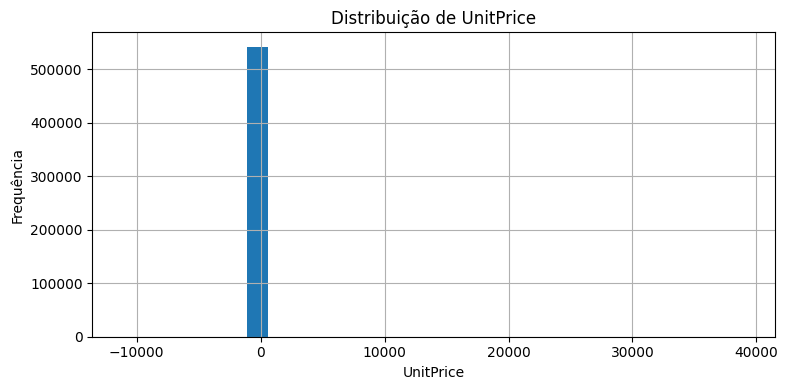

In [ ]:
plot_distribuicao_numerica(df, "UnitPrice") #Com outliers

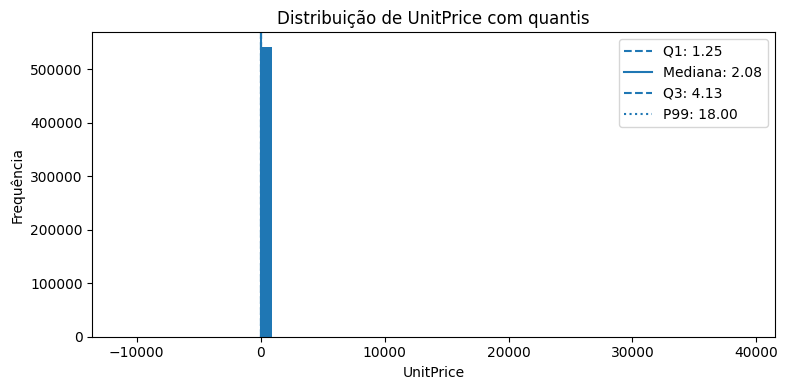

In [ ]:
plot_distribuicao_com_quantis(df, "UnitPrice")

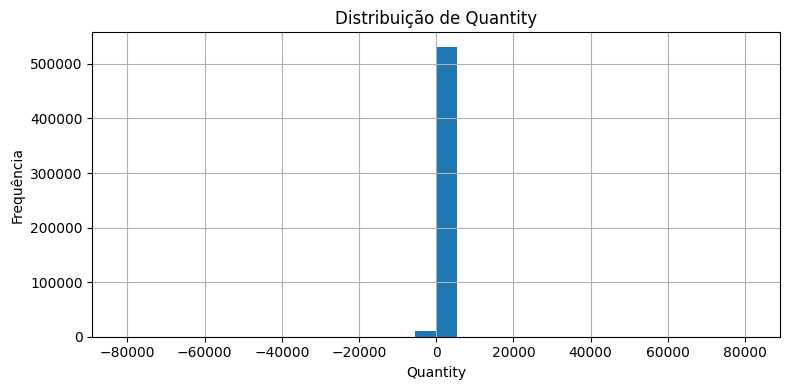

In [ ]:
plot_distribuicao_numerica(df, "Quantity") #Com outliers

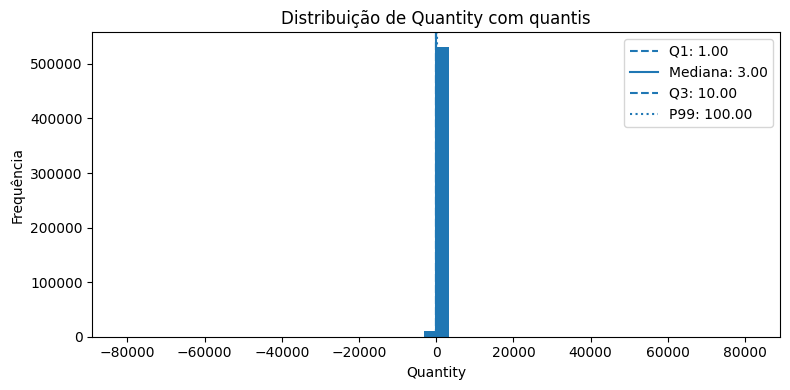

In [ ]:
plot_distribuicao_com_quantis(df, "Quantity")

In [ ]:
def plot_distribuicao_numerica(df: pd.DataFrame, coluna: str) -> None:
    dados = df[coluna].dropna()

    # remove valores inválidos
    dados = dados[dados > 0]

    #remove outliers (top 1%)
    limite = dados.quantile(0.99)
    dados = dados[dados <= limite]

    plt.figure(figsize=(8, 4))
    plt.hist(dados, bins=50)
    plt.title(f"Distribuição de {coluna}")
    plt.xlabel(coluna)
    plt.ylabel("Frequência")
    plt.tight_layout()
    plt.show()

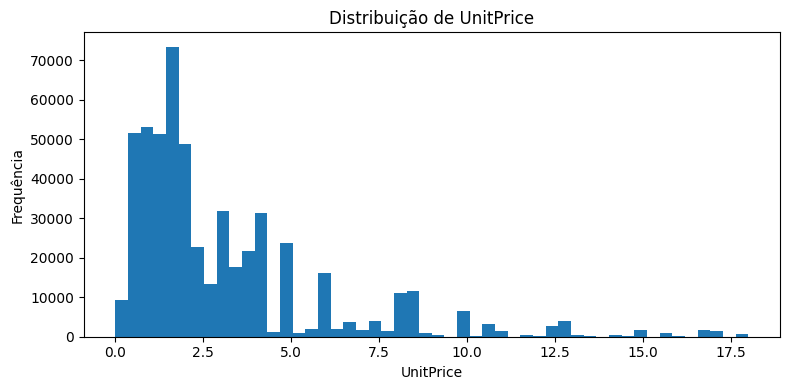

In [ ]:
plot_distribuicao_numerica(df, "UnitPrice") #Sem outliers

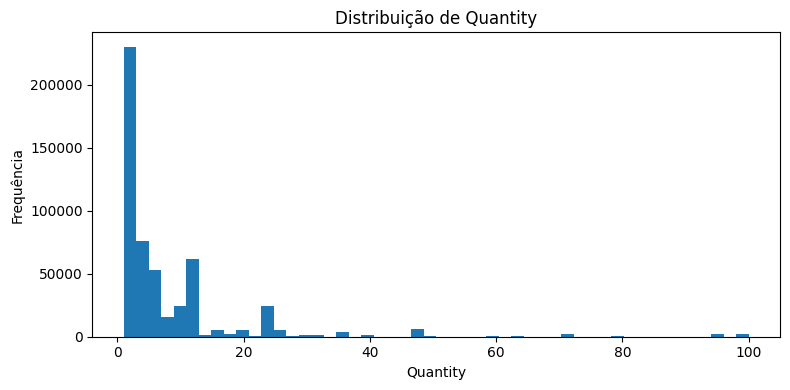

In [ ]:
plot_distribuicao_numerica(df, "Quantity") #Sem outliers

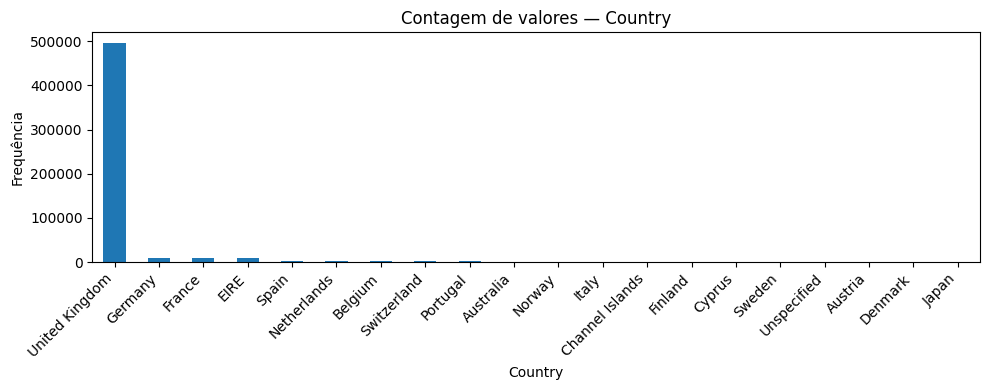

In [ ]:
plot_contagem_categorica(df,"Country")

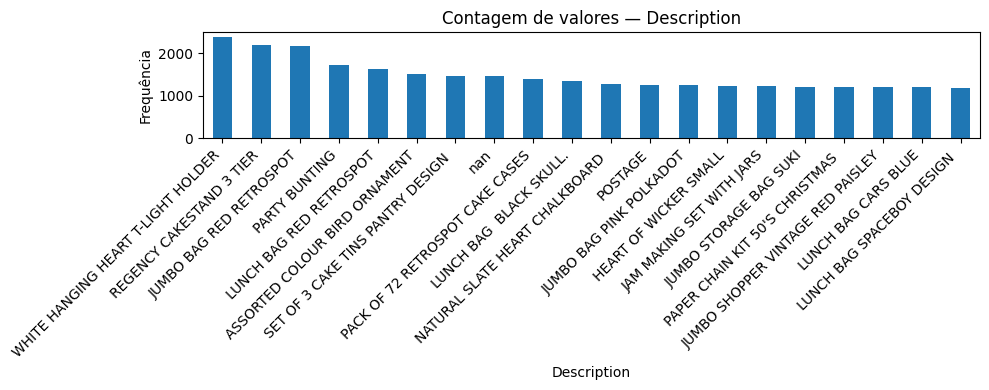

In [ ]:
plot_contagem_categorica(df,"Description")

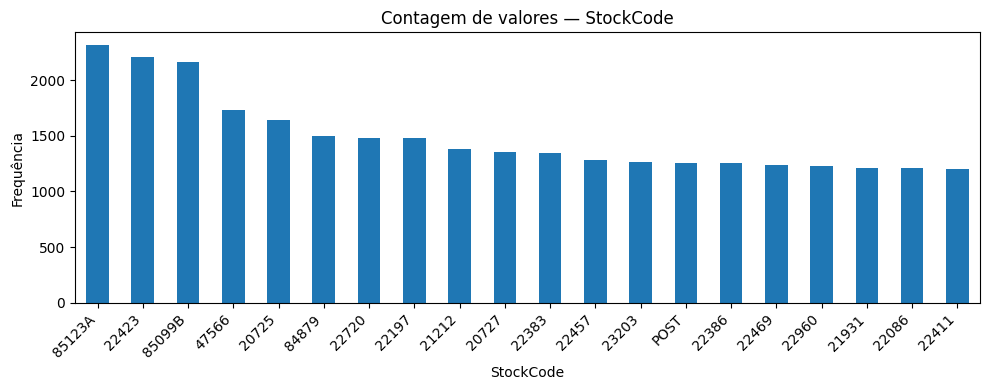

In [ ]:
plot_contagem_categorica(df,"StockCode")

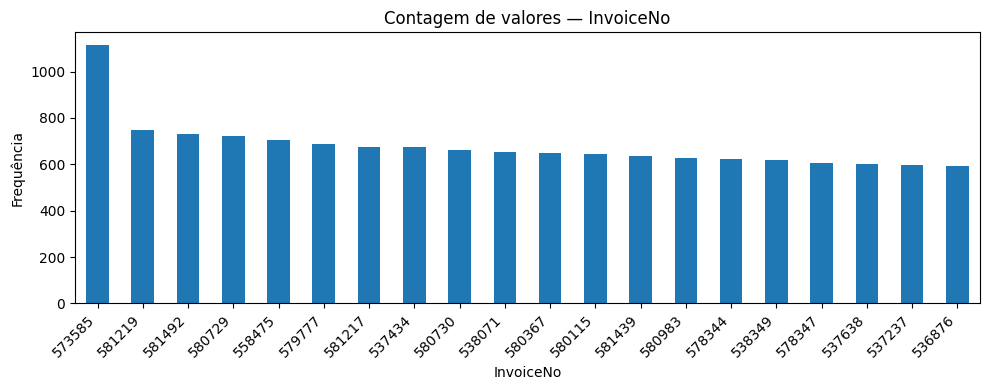

In [ ]:
plot_contagem_categorica(df,"InvoiceNo")

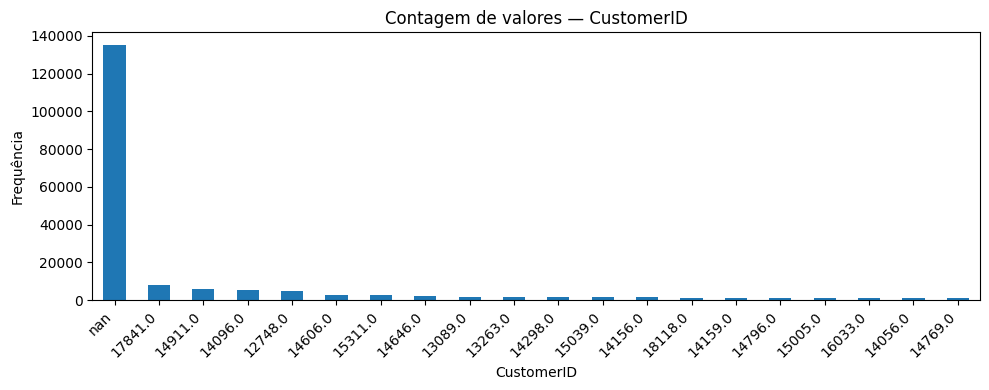

In [ ]:
plot_contagem_categorica(df,"CustomerID") 

In [ ]:
# Detecção simples de outliers em variáveis numéricas usando IQR
# Esta função é um exemplo. O grupo deve avaliar se o critério faz sentido para cada atributo.

def detectar_outliers_iqr(df: pd.DataFrame, coluna: str) -> pd.DataFrame:
    serie = df[coluna].dropna()

    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)
    iqr = q3 - q1

    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr

    outliers = df[(df[coluna] < limite_inferior) | (df[coluna] > limite_superior)]

    print(f"Coluna: {coluna}")
    print(f"Q1: {q1}")
    print(f"Q3: {q3}")
    print(f"IQR: {iqr}")
    print(f"Limite inferior: {limite_inferior}")
    print(f"Limite superior: {limite_superior}")
    print(f"Número de outliers: {len(outliers)}")

    return outliers

# Exemplo de uso:
# outliers = detectar_outliers_iqr(df, "[COLUNA_NUMERICA]")
# display(outliers.head())


In [ ]:
outliers = detectar_outliers_iqr(df, "Quantity")
display(outliers.head())

Coluna: Quantity
Q1: 1.0
Q3: 10.0
IQR: 9.0
Limite inferior: -12.5
Limite superior: 23.5
Número de outliers: 58619


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,01/12/2010 08:34,1.69,13047.0,United Kingdom
26,536370,22728,ALARM CLOCK BAKELIKE PINK,24,01/12/2010 08:45,3.75,12583.0,France
27,536370,22727,ALARM CLOCK BAKELIKE RED,24,01/12/2010 08:45,3.75,12583.0,France
30,536370,21883,STARS GIFT TAPE,24,01/12/2010 08:45,0.65,12583.0,France
31,536370,10002,INFLATABLE POLITICAL GLOBE,48,01/12/2010 08:45,0.85,12583.0,France


In [ ]:
outliers = detectar_outliers_iqr(df, "UnitPrice")
display(outliers.head())

Coluna: UnitPrice
Q1: 1.25
Q3: 4.13
IQR: 2.88
Limite inferior: -3.0700000000000003
Limite superior: 8.45
Número de outliers: 39627


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
16,536367,22622,BOX OF VINTAGE ALPHABET BLOCKS,2,01/12/2010 08:34,9.95,13047.0,United Kingdom
45,536370,POST,POSTAGE,3,01/12/2010 08:45,18.00,12583.0,France
65,536374,21258,VICTORIAN SEWING BOX LARGE,32,01/12/2010 09:09,10.95,15100.0,United Kingdom
141,C536379,D,Discount,-1,01/12/2010 09:41,27.50,14527.0,United Kingdom
151,536382,22839,3 TIER CAKE TIN GREEN AND CREAM,2,01/12/2010 09:45,14.95,16098.0,United Kingdom


O método IQR identifica um grande número de outliers nas variáveis Quantity e UnitPrice. Isso ocorre devido à forte assimetria da distribuição e à presença de compras em grande volume, indicando que o método pode não ser totalmente adequado para esse tipo de dado.

In [ ]:
def detectar_outliers_percentil(
    df: pd.DataFrame, 
    coluna: str, 
    lower_q: float = 0.01, 
    upper_q: float = 0.99,
    apenas_positivos: bool = True
) -> pd.DataFrame:
    
    serie = df[coluna].dropna()

    if apenas_positivos:
        serie = serie[serie > 0]

    limite_inferior = serie.quantile(lower_q)
    limite_superior = serie.quantile(upper_q)

    outliers = df[
        (df[coluna] < limite_inferior) | 
        (df[coluna] > limite_superior)
    ]

    print(f"Coluna: {coluna}")
    print(f"Percentil inferior ({lower_q*100}%): {limite_inferior}")
    print(f"Percentil superior ({upper_q*100}%): {limite_superior}")
    print(f"Número de outliers: {len(outliers)}")

    return outliers

In [ ]:
outliers = detectar_outliers_percentil(df, "Quantity")
display(outliers.head())

Coluna: Quantity
Percentil inferior (1.0%): 1.0
Percentil superior (99.0%): 100.0
Número de outliers: 15574


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
96,536378,21212,PACK OF 72 RETROSPOT CAKE CASES,120,01/12/2010 09:37,0.42,14688.0,United Kingdom
141,C536379,D,Discount,-1,01/12/2010 09:41,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,01/12/2010 09:49,4.65,15311.0,United Kingdom
178,536387,79321,CHILLI LIGHTS,192,01/12/2010 09:58,3.82,16029.0,United Kingdom
179,536387,22780,LIGHT GARLAND BUTTERFILES PINK,192,01/12/2010 09:58,3.37,16029.0,United Kingdom


In [ ]:
outliers = detectar_outliers_percentil(df, "UnitPrice")
display(outliers.head())

Coluna: UnitPrice
Percentil inferior (1.0%): 0.29
Percentil superior (99.0%): 18.0
Número de outliers: 11618


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,01/12/2010 09:41,27.50,14527.0,United Kingdom
168,536385,22783,SET 3 WICKER OVAL BASKETS W LIDS,1,01/12/2010 09:56,19.95,17420.0,United Kingdom
219,536390,20668,DISCO BALL CHRISTMAS DECORATION,288,01/12/2010 10:19,0.10,17511.0,United Kingdom
246,536392,22827,RUSTIC SEVENTEEN DRAWER SIDEBOARD,1,01/12/2010 10:29,165.00,13705.0,United Kingdom
294,536396,22803,IVORY EMBROIDERED QUILT,2,01/12/2010 10:51,35.75,17850.0,United Kingdom


Devido à limitação do método IQR em distribuições altamente assimétricas, optou-se pela utilização de limites baseados em percentis. Essa abordagem permite identificar valores extremos de forma mais robusta, preservando compras legítimas em grande volume e reduzindo o impacto de observações raras.

## 2.2 Análise visual — interpretação

As visualizações exploratórias evidenciam padrões importantes na distribuição dos dados, indo além de uma simples descrição gráfica. Observa-se uma forte concentração de valores em categorias específicas, como o predomínio do país United Kingdom e a recorrência de determinados produtos, como “WHITE HANGING HEART T-LIGHT HOLDER”. Esse comportamento indica que uma pequena parcela de categorias concentra grande parte das ocorrências, caracterizando uma distribuição desigual.

Também foram identificados valores extremos (outliers) nas variáveis numéricas Quantity e UnitPrice, incluindo valores muito elevados e negativos. Esses pontos destoam significativamente da maioria das observações e estão associados, em grande parte, a devoluções ou inconsistências nos registros, podendo distorcer tanto as visualizações quanto as análises subsequentes.

Além disso, verifica-se a presença de categorias muito raras, especialmente em variáveis como StockCode e Description, que apresentam alta cardinalidade. Muitos produtos aparecem poucas vezes, o que pode dificultar a geração de regras de associação relevantes, já que itens raros tendem a possuir baixo suporte.

Outro ponto relevante é a alta recorrência de determinados identificadores de transação (InvoiceNo), que aparecem com frequência significativamente maior que outros. Esse comportamento indica a existência de cestas de compras com múltiplos itens associados à mesma fatura, reforçando a natureza transacional do dataset e sua adequação para análise de cesta de compras.

O conjunto de dados apresenta ainda um claro desbalanceamento, tanto geográfico — com forte predominância do Reino Unido — quanto na distribuição de produtos, onde poucos itens concentram grande parte das vendas. Esse desbalanceamento pode influenciar diretamente os resultados da mineração, favorecendo a geração de regras envolvendo itens mais frequentes e reduzindo a diversidade dos padrões descobertos.

Esses padrões impactam diretamente a tarefa de mineração de dados. A presença de outliers e valores inconsistentes pode comprometer a qualidade das regras geradas, enquanto a alta frequência de determinados itens pode levar à produção de regras triviais, com pouco valor analítico. Por outro lado, a existência de cestas com múltiplos itens e a recorrência de produtos populares favorecem a identificação de associações relevantes.

Por fim, algumas visualizações indicam riscos associados às diretrizes do projeto, especialmente em relação à eficiência e interpretabilidade. A alta cardinalidade e o grande volume de dados podem levar à explosão combinatória na geração de itemsets, afetando o desempenho computacional. Além disso, o desbalanceamento pode gerar um grande número de regras redundantes ou pouco informativas, dificultando sua interpretação e explicabilidade. Dessa forma, torna-se necessário adotar estratégias como ajuste de suporte mínimo e seleção criteriosa das regras para garantir resultados mais úteis e eficientes.

## 2.3 Problemas de qualidade dos dados

| Problema identificado | Evidência | Decisão tomada | Justificativa |
|---|---|---|---|
| Valores ausentes em Description | Existem 1454 valores ausentes em Description | REMOVER | Registros sem descrição não permitem identificar o item, inviabilizando a construção da matriz transacional e a geração de regras de associação.|
| Duplicatas | Existem 5268 valores duplicados | REMOVER | Linhas duplicadas podem inflar artificialmente a frequência de itens e distorcer medidas como suporte, levando a regras enviesadas.|
| Negativos/outliers em Quantity | Existem 10624 valores negativos em Quantity | REMOVER OS NEGATIVOS | Valores negativos representam devoluções, que não refletem coocorrência de compra. Sua remoção garante que apenas eventos de aquisição sejam considerados. |
| Categorias raras | Muitas transações envolvem apenas 1 item | REMOVER | Itens com baixa frequência não geram padrões estatisticamente relevantes e aumentam a esparsidade da matriz, prejudicando eficiência e qualidade das regras. |
| Atributos sensíveis ou identificadores | Ausência de uso no modelo | Ignorar no modelo | O modelo trabalha apenas com coocorrência de itens, não utilizando atributos sensíveis diretamente. Ainda assim, CustomerID pode ser considerado identificador indireto, exigindo cuidado ético no uso.|

### Observação sobre responsabilidade

As decisões de preparação de dados foram guiadas pelas diretrizes de escalabilidade, eficiência e explicabilidade, o que influencia diretamente tanto o tipo de informação mantida quanto a forma como os padrões serão extraídos e interpretados.

A remoção de valores ausentes em Description, duplicatas e registros com Quantity negativo contribui principalmente para a eficiência e escalabilidade do pipeline, reduzindo o volume de dados processados e eliminando inconsistências que poderiam aumentar o custo computacional e prejudicar o desempenho do algoritmo. No caso dos valores negativos (devoluções), sua remoção também reforça a explicabilidade do modelo, uma vez que o objetivo é analisar coocorrência de itens em compras, e não eventos de retorno, que introduziriam uma camada adicional de interpretação mais complexa.

A decisão de remover categorias raras e transações com apenas um item está diretamente relacionada à escalabilidade do método FP-Growth (FP-Growth algorithm). Ao reduzir a esparsidade da matriz transacional e eliminar itens de baixa frequência, o algoritmo consegue operar com maior eficiência computacional, além de gerar regras mais estáveis e interpretáveis. Em contrapartida, essa escolha prioriza padrões mais frequentes, o que melhora a legibilidade dos resultados, mas reduz a cobertura de nichos menos representativos.

Por fim, a decisão de ignorar atributos identificadores ou sensíveis (como CustomerID) fortalece a explicabilidade do modelo, já que a análise é restrita exclusivamente à coocorrência de itens, facilitando a interpretação das regras de associação. Além disso, essa escolha contribui para a eficiência do processamento, ao evitar o aumento desnecessário da dimensionalidade do problema. Como consequência, perde-se a possibilidade de análises individualizadas por cliente, mas ganha-se um modelo mais direto, leve e interpretável.

Em síntese, as decisões adotadas priorizam um pipeline mais escalável e eficiente, ao mesmo tempo em que mantêm o foco na interpretabilidade das regras geradas, ainda que isso implique redução na granularidade de algumas informações.

In [ ]:
#Cálculos para as evidências

print(df.duplicated().sum())
print((df["Quantity"] < 0).sum())

5268
10624


In [ ]:
import pandas as pd
import numpy as np

def preparar_dados(
    df: pd.DataFrame,
    min_itens_por_transacao: int = 1,
    min_freq_item: int = 5
) -> pd.DataFrame:
    """
    Preparação de dados para mineração de regras de associação (FP-Growth).
    """

    df_prep = df.copy()

    # ------------------------------------------------------------
    # 1. Remover duplicatas
    # ------------------------------------------------------------
    df_prep = df_prep.drop_duplicates()

    # ------------------------------------------------------------
    # 2. Tratamento de valores nulos
    # ------------------------------------------------------------

    # Remove linhas sem descrição do item (não identificável)
    if "Description" in df_prep.columns:
        df_prep = df_prep.dropna(subset=["Description"])

    
    # ------------------------------------------------------------
    # 2.1 Remover transações canceladas (InvoiceNo começa com 'C')
    # ------------------------------------------------------------
    if "InvoiceNo" in df_prep.columns:
        df_prep = df_prep[~df_prep["InvoiceNo"].astype(str).str.startswith("C")]

    # ------------------------------------------------------------
    # 3. Remoção de devoluções (valores negativos)
    # ------------------------------------------------------------
    if "Quantity" in df_prep.columns:
        df_prep = df_prep[df_prep["Quantity"] > 0]

    # ------------------------------------------------------------
    # 4. Criar variável transacional (cesta de compras)
    # ------------------------------------------------------------
    # Cada linha representa item comprado em uma transação
    if not {"InvoiceNo", "Description"}.issubset(df_prep.columns):
        raise ValueError("O dataset precisa conter 'InvoiceNo' e 'Description'.")

    basket = (
        df_prep.groupby(["InvoiceNo", "Description"])["Quantity"]
        .sum()
        .unstack()
        .fillna(0)
    )

    # ------------------------------------------------------------
    # 5. Binarização (presença/ausência)
    # ------------------------------------------------------------
    basket = (basket > 0).astype(int)

    # ------------------------------------------------------------
    # 6. Remover itens raros
    # ------------------------------------------------------------
    item_freq = basket.sum(axis=0)
    itens_filtrados = item_freq[item_freq >= min_freq_item].index
    basket = basket[itens_filtrados]

    # ------------------------------------------------------------
    # 7. Remover transações muito pequenas
    # ------------------------------------------------------------
    basket = basket[basket.sum(axis=1) >= min_itens_por_transacao]

    # ------------------------------------------------------------
    # 8. Resetar índice para uso em algoritmos
    # ------------------------------------------------------------
    basket = basket.reset_index(drop=True)

    return basket

In [ ]:
df_prep = preparar_dados(df)

In [ ]:
display(df_prep.head())

Description,4 PURPLE FLOCK DINNER CANDLES,50'S CHRISTMAS GIFT BAG LARGE,DOLLY GIRL BEAKER,I LOVE LONDON MINI BACKPACK,NINE DRAWER OFFICE TIDY,OVAL WALL MIRROR DIAMANTE,RED SPOT GIFT BAG LARGE,SET 2 TEA TOWELS I LOVE LONDON,SPACEBOY BABY GIFT SET,TRELLIS COAT RACK,...,ZINC T-LIGHT HOLDER STARS SMALL,ZINC TOP 2 DOOR WOODEN SHELF,ZINC WILLIE WINKIE CANDLE STICK,ZINC WIRE KITCHEN ORGANISER,ZINC WIRE SWEETHEART LETTER TRAY,adjustment,amazon,check,found,had been put aside
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
df_prep.sum(axis=0).value_counts()

5       78
8       74
7       62
6       60
10      51
        ..
971      1
1100     1
512      1
835      1
456      1
Name: count, Length: 610, dtype: int64

## 2.4 Justificativa da preparação dos dados

A preparação dos dados foi realizada para adequar o dataset à mineração de padrões frequentes e geração de regras de associação com FP-Growth, seguindo diretrizes de eficiência, escalabilidade e explicabilidade.

Foram removidas colunas não utilizadas diretamente na análise, como atributos administrativos ou identificadores adicionais, mantendo apenas InvoiceNo, Description e Quantity, pois são suficientes para representar a estrutura transacional.

Valores ausentes em Description foram removidos por impossibilitarem a identificação do item, enquanto registros com CustomerID ausente foram excluídos para garantir consistência estrutural do dataset. Duplicatas também foram eliminadas para evitar distorções na frequência de itens.

Foram removidas transações canceladas (InvoiceNo com prefixo “C”) e outliers em Quantity (valores negativos), que representam devoluções e não refletem coocorrência de compra. Essas remoções garantem que apenas eventos de aquisição sejam analisados.

As variáveis categóricas foram tratadas por meio da transformação da base em uma matriz transacional binária esparsa (item × transação), onde cada entrada indica presença ou ausência do item na compra. Esse processo constitui uma discretização dos dados, eliminando a necessidade de normalização ou codificação adicional, uma vez que o FP-Growth opera apenas sobre coocorrência.

Além disso, foram removidos itens raros e transações com poucos itens, reduzindo a esparsidade extrema da matriz e aumentando a eficiência computacional do algoritmo.

Essas decisões introduzem riscos como perda de informação quantitativa, exclusão de padrões raros e possível viés pela filtragem de dados. No entanto, tais escolhas são justificadas pelo objetivo do FP-Growth, que prioriza escalabilidade e eficiência em bases grandes e esparsas, além de gerar regras interpretáveis e explicativas baseadas exclusivamente em coocorrência de itens.

> A preparação dos dados não deve ser apenas uma sequência de comandos. Toda decisão relevante precisa de justificativa técnica.


## 2.5 Interações com LLM — Data Understanding & Data Preparation

### Subtarefa comparável

Nesta etapa, as duas trilhas devem receber a mesma subtarefa geral.

**Subtarefa escolhida:** propor estratégias de limpeza, transformação e preparação dos dados para a tarefa de mineração

---

### Trilha A — baseline

**Modelo utilizado:** Gemini Pro

**Data de acesso:** 01/05/2026 

**Link da conversa:** 

#### Prompt principal — baseline

"Tenho um dataset de transações de varejo online com as seguintes colunas:
InvoiceNo, StockCode, Description, Quantity, InvoiceDate, UnitPrice, CustomerID, Country.

A tarefa de mineração é realizar Market Basket Analysis (análise de cesta de compras), com o objetivo de identificar padrões de coocorrência entre produtos e gerar regras de associação.

Sugira uma estratégia de Data Understanding e Data Preparation adequada para essa tarefa. Considere:

- identificação de problemas de qualidade dos dados (valores ausentes, outliers, inconsistências);
- análise das características das variáveis (tipos, cardinalidade, distribuição);
- decisões de limpeza e filtragem dos dados;
- transformação dos dados para formato transacional (cestas de compra);
- possíveis limitações e impactos dessas decisões na mineração.

A resposta deve ser estruturada, clara e voltada para aplicação prática no contexto de mineração de dados."

#### Síntese da resposta da LLM

O dataset apresenta diversos problemas de qualidade típicos de dados reais, como valores ausentes, cancelamentos, inconsistências e alta assimetria nas variáveis numéricas. Na fase de Data Understanding, identificam-se variáveis com alta cardinalidade, forte desbalanceamento (principalmente no Reino Unido) e presença de ruídos, como devoluções (Quantity < 0) e códigos não relacionados a produtos.

Na etapa de Data Preparation, é necessário realizar uma limpeza rigorosa: remover cancelamentos, filtrar valores inválidos (Quantity > 0 e UnitPrice > 0), excluir códigos que não representam produtos e padronizar descrições. Valores ausentes em CustomerID podem ser mantidos, pois a análise é baseada em transações (InvoiceNo), não em clientes.

Em seguida, os dados devem ser transformados para o formato de cesta de compras, agrupando por transação e convertendo os produtos em uma matriz binária (presença/ausência), adequada para algoritmos como FP-Growth.

Por fim, destaca-se que essas decisões impactam a mineração: a base se torna esparsa, pode haver viés geográfico e cestas com apenas um item devem ser removidas. A escolha de algoritmos eficientes, como FP-Growth, é essencial para lidar com essas limitações.

---

### Trilha B — guiada por diretrizes

**Modelo utilizado:** Gemini Pro  
**Data de acesso:** 02/05/2026

**Link da conversa:** https://gemini.google.com/share/50b48581b1ae

#### Prompt principal — guiado

```text
Tenho um dataset de transações de varejo online com as seguintes colunas: InvoiceNo, StockCode, Description, Quantity, InvoiceDate, UnitPrice, CustomerID, Country.

A tarefa de mineração é realizar Market Basket Analysis (análise de cesta de compras), com o objetivo de identificar padrões de coocorrência entre produtos e gerar regras de associação.

Sugira uma estratégia de Data Understanding e Data Preparation adequada para essa tarefa. Considere:

identificação de problemas de qualidade dos dados (valores ausentes, outliers, inconsistências);
análise das características das variáveis (tipos, cardinalidade, distribuição);
decisões de limpeza e filtragem dos dados;
transformação dos dados para formato transacional (cestas de compra);
possíveis limitações e impactos dessas decisões na mineração.

Considere explicitamente as seguintes diretrizes de IA responsável:

Explicabilidade: As regras de associação precisam ser compreensíveis para gerar valor de negócio (ex: entender por que produtos são comprados juntos).
Eficiência e Escalabilidade: O dataset é grande e algoritmos como Apriori podem gerar explosão combinatória, exigindo otimização de tempo e memória.

Ao sugerir a preparação, indique:

possíveis atributos sensíveis, se houver;
riscos de viés ou perda de informação;
decisões que devem ser documentadas;
transformações necessárias;
limitações e trade-offs.

Além da descrição do problema, indique riscos, limitações e critérios que deveriam orientar a solução de mineração de dados.
```

#### Síntese da resposta da LLM

Na etapa de Data Understanding, analisa-se a estrutura do dataset e identifica-se problemas de qualidade que poderiam impactar a mineração de dados, como transações canceladas, quantidades negativas, preços zerados, valores ausentes e códigos que não representam produtos reais. Também observa-se que a maior parte das compras está concentrada no Reino Unido, o que pode gerar viés geográfico, além da existência de compras em grande volume associadas a clientes atacadistas.

Na fase de Data Preparation, definiu-se a remoção de registros inconsistentes, como cancelamentos, devoluções e itens não comerciais, além do tratamento de valores inválidos. Optou-se por manter transações sem CustomerID, pois ainda representam compras reais e sua exclusão causaria perda significativa de informação. Em seguida, os dados foram transformados para o formato transacional, agrupando produtos por número de fatura e convertendo a base em uma matriz binária de presença ou ausência de itens em cada cesta de compra.

Considerando as diretrizes de IA responsável, o trabalho priorizou eficiência e escalabilidade, escolhendo o algoritmo FP-Growth por ser mais adequado para grandes volumes de dados do que o Apriori. Também buscou explicabilidade, utilizando descrições dos produtos em vez de códigos e interpretando as regras por métricas como suporte, confiança e lift, de forma que os resultados fossem compreensíveis e úteis para o negócio.

Por fim, foi-se documentado os riscos e limitações, como sazonalidade, influência de atacadistas e possível perda de informação após os filtros aplicados. O sucesso da solução foi definido pela geração de regras estatisticamente relevantes, interpretáveis e aplicáveis em ações práticas, como recomendações de produtos, promoções combinadas e estratégias de cross-selling.

## 2.6 Comparação crítica — Data Understanding & Preparation

| Aspecto | Trilha A — baseline | Trilha B — guiada | Decisão do grupo |
|---|---|---|---|
| Tratamento de nulos | Manter os registros com CustomerID nulo, mas remover registros com Description ou StockCode nulos (ou inválidos). | [SUGESTÃO] | [ACEITAR/REJEITAR/CORRIGIR] |
| Tratamento de outliers | Remoção de valores negativos em Quantity e valores zerados/negativos em UnitPrice. Manutenção de outliers positivos extremos (vendas de alto volume). | [SUGESTÃO] | [ACEITAR/REJEITAR/CORRIGIR] |
| Atributos sensíveis | Identifica ausência de atributos sensíveis | [SUGESTÃO] | [ACEITAR/REJEITAR/CORRIGIR] |
| Codificação de variáveis | Transformação da estrutura tabular transacional (uma linha por item) para uma matriz binária esparsa (One-Hot Encoding lógico por agrupamento) ou listas de transações (Transaction Lists). | [SUGESTÃO] | [ACEITAR/REJEITAR/CORRIGIR] |
| Redução de dimensionalidade | Remoção de faturas unitárias (cestas com apenas 1 item) e, opcionalmente, poda de itens de cauda longa (itens raros que aparecem em menos de 0,1% ou 0,5% das cestas).| [SUGESTÃO] | [ACEITAR/REJEITAR/CORRIGIR] |
| Justificativa técnica | Pontos fortes: boa coerência com market basket analysis, decisões alinhadas com FP-Growth, reconhecimento de limitações; Pontos fracos: ausência de critérios formais (ex: suporte mínimo) e algumas justificativas simplificadas demais.| [ANALISAR] | [DECISÃO] |
| Riscos e limitações | Identifica alguns pontos (esparsidade, viés) | [ANALISAR] | [DECISÃO] |

### Análise crítica

[INSERIR ANÁLISE COMPARATIVA]

A análise deve deixar claro:

- o que a LLM sugeriu corretamente;
- o que estava incompleto;
- o que estava tecnicamente errado;
- o que foi aceito;
- o que foi rejeitado;
- o que foi corrigido pelo grupo.


# 3. Modeling

Nesta seção, o grupo deve documentar a modelagem proposta com apoio da LLM.

Para o TP de padrões frequentes, a modelagem pode envolver, por exemplo:

- Apriori;
- FP-Growth;
- Eclat;
- regras de associação.

Para outros TPs, substituir pelos algoritmos pertinentes, como algoritmos de agrupamento ou classificação.

O foco da Fase 2 é comparar criticamente as soluções sugeridas pela LLM nas duas trilhas e, quando possível, executar testes preliminares para verificar a viabilidade das sugestões.


## 3.1 Interações com LLM — Modeling

### Subtarefa comparável

**Subtarefa escolhida:** propor algoritmos, parâmetros, métricas e estratégia de avaliação para a tarefa

---

### Trilha A — baseline

**Modelo utilizado:** Gemini Pro
**Data de acesso:** 01/05/2026 
**Link da conversa:** [INSERIR LINK DA CONVERSA]

#### Prompt principal — baseline

"Com base no UCI Online Retail Dataset (já em formato de matriz transacional binária), proponha uma estratégia de mineração de dados e geração de  regras de associação.

Inclua: seleção e comparação de algoritmos (Apriori, FP-Growth, Eclat), definição e ajuste de parâmetros (suporte, confiança e lift), geração e filtragem de regras, métricas de avaliação, comparação de desempenho entre abordagens e interpretação dos resultados para aplicações em recomendação e marketing."

#### Síntese da resposta da LLM

"Modelo Final: O FP-Growth consolidado através dos filtros de Lift ($> 1.5$), Confiança ($> 0.35$), Suporte ($>0.02$) e Convicção ($> 1.2$) é a estrutura definitiva para este problema, balanceando eficiência computacional com precisão analítica.

Sendo a Confiança: $$ \text{Confiança}(A \rightarrow B) = \frac{\text{Suporte}(A \cup B)}{\text{Suporte}(A)} $$ 

O Lift: $$ \text{Lift}(A \rightarrow B) = \frac{\text{Confiança}(A \rightarrow B)}{\text{SuporteRelativo}(B)} $$

A Convicção: $$ \text{Convicção}(A \rightarrow B) = \frac{1 - \text{Suporte}(B)}{1 - \text{Confiança}(A \rightarrow B)} $$

Limitações Atuais: A análise de cesta ignora a dimensão temporal e sequencial da compra. Sabemos que os itens foram comprados juntos na mesma fatura, mas não sabemos em qual ordem foram adicionados ao carrinho, nem se a compra de um item induz a compra de outro meses depois."

---

### Trilha B — guiada por diretrizes

**Modelo utilizado:** Gemini Pro

**Data de acesso:** 02/05/2026 

**Link da conversa:** https://gemini.google.com/share/fbcba6dba3a7

#### Prompt principal — guiado

```text
Com base no UCI Online Retail Dataset (já em formato de matriz transacional binária), proponha uma estratégia de mineração de dados e geração de  regras de associação.

Inclua: seleção e comparação de algoritmos (Apriori, FP-Growth, Eclat), definição e ajuste de parâmetros (suporte, confiança e lift), geração e filtragem de regras, métricas de avaliação, comparação de desempenho entre abordagens e interpretação dos resultados para aplicações em recomendação e marketing.

Considere explicitamente as seguintes diretrizes de IA responsável:
Explicabilidade: As regras de associação precisam ser compreensíveis para gerar valor de negócio (ex: entender por que produtos são comprados juntos).
Eficiência e Escalabilidade: O dataset é grande e algoritmos como Apriori podem gerar explosão combinatória, exigindo otimização de tempo e memória.

Na resposta, indique:
- algoritmos adequados;
- parâmetros iniciais;
- métricas de avaliação;
- riscos metodológicos;
- impacto das diretrizes nas escolhas;
- trade-offs entre desempenho, interpretabilidade, custo computacional e qualidade da solução.
```

#### Síntese da resposta da LLM

Na etapa de modelagem, o grupo comparou os algoritmos Apriori, Eclat e FP-Growth, concluindo que o FP-Growth era a melhor escolha para o projeto por apresentar maior eficiência e escalabilidade em bases volumosas, reduzindo tempo de processamento e uso de memória em relação ao Apriori.

Para o ajuste inicial dos parâmetros, foi sugerido utilizar suporte mínimo de 0,01 (1%), buscando equilíbrio entre relevância e quantidade de regras geradas. Valores muito altos, como 5%, tenderiam a capturar apenas associações óbvias, enquanto valores muito baixos, como 0,1%, poderiam gerar excesso de regras irrelevantes. Também foi adotada confiança mínima de 0,3 (30%), garantindo probabilidade razoável de ocorrência das regras, além de priorizar associações com Lift > 1,2, indicador de dependência real entre os itens.

Após a mineração, considerou-se importante filtrar regras triviais ou redundantes e priorizar aquelas com maior potencial de negócio, especialmente para recomendação de produtos e cross-selling. Para fins de explicabilidade, regras com Lift = 5, por exemplo, podem ser interpretadas como clientes tendo 5 vezes mais chance de comprar determinado item ao adquirir outro produto relacionado.

Também foram identificados riscos metodológicos, como influência excessiva de itens muito populares, produtos de baixo valor (como itens de £0,01) e sensibilidade aos parâmetros escolhidos. Além disso, regras muito complexas dificultam a aplicação prática, sendo preferíveis associações simples de 1 para 1 ou 2 para 1 itens.

Por fim, o sucesso da solução foi avaliado por indicadores como número de regras úteis com Lift > 1, comparação do tempo de execução entre FP-Growth e Apriori e análise de sensibilidade ao variar o suporte de 1% para 0,5%, verificando a estabilidade dos resultados.

## 3.2 Comparação das soluções sugeridas pela LLM

| Elemento | Trilha A — baseline | Trilha B — guiada | Diferença concreta? | Comentário do grupo |
|---|---|---|---|---|
| Algoritmos sugeridos | FP-Growth | [PREENCHER] | [SIM/NÃO] | [ANALISAR] |
| Parâmetros sugeridos | Limites para o suporte, confiança, lift e convicção (definidos empiricamente) | [PREENCHER] | [SIM/NÃO] | [ANALISAR] |
| Métricas sugeridas | Suporte, lift, confiança e convicção | [PREENCHER] | [SIM/NÃO] | [ANALISAR] |
| Preparação exigida | Matriz transacional binária (basket) já pronta | [PREENCHER] | [SIM/NÃO] | [ANALISAR] |
| Interpretabilidade | Foco em regras diretas de coocorrência | [PREENCHER] | [SIM/NÃO] | [ANALISAR] |
| Custo computacional | Baixo (FP-Growth direto) | [PREENCHER] | [SIM/NÃO] | [ANALISAR] |
| Riscos ou limitações | Sensibilidade ao suporte | [SIM/NÃO] | [ANALISAR] |
| Aderência às diretrizes | A Trilha A apresenta alta escalabilidade e eficiência computacional, devido ao uso direto do FP-Growth, que reduz o custo de geração de itemsets frequentes. No entanto, sua explicabilidade é parcial, pois embora as regras geradas sejam facilmente interpretáveis, o processo de modelagem é menos transparente por não incluir a exploração sistemática de parâmetros, o que limita a justificativa das escolhas metodológicas. | [PREENCHER] | [SIM/NÃO] | [ANALISAR] |


### Síntese

[INSERIR ANÁLISE COMPARATIVA]

A comparação deve destacar evidências, não impressões vagas.


## 3.3 Template de modelagem para padrões frequentes

Use esta subseção se o TP atual envolver mineração de padrões frequentes. Caso o TP atual seja de agrupamento ou classificação, esta subseção pode ser removida ou mantida como referência não executada.

> **Atenção:** suporte, confiança e lift devem ser interpretados no contexto do dataset. Valores de suporte muito baixos podem gerar muitas regras pouco úteis; valores muito altos podem ocultar padrões relevantes.


In [39]:
transacoes = df_prep

In [40]:
# Exemplo de preparação para mineração de padrões frequentes
# Use esta célula apenas se o TP atual for de padrões frequentes.
# Para classificação ou agrupamento, substituir por uma preparação adequada.

#Essa célula não foi utilizada pelo grupo pois a matriz transacional binária esparsa já foi gerada anteriormente
def gerar_transacoes_de_coluna(df: pd.DataFrame, coluna: str, separador: str = ",") -> list:
    # Gera uma lista de transações a partir de uma coluna textual.
    # Exemplo: "leite, pão, manteiga" -> ["leite", "pão", "manteiga"]
    transacoes = []

    for valor in df[coluna].dropna():
        itens = [
            item.strip().lower()
            for item in str(valor).split(separador)
            if item.strip()
        ]

        if len(itens) > 0:
            transacoes.append(itens)

    return transacoes

# Exemplo de uso:
# transacoes = gerar_transacoes_de_coluna(df_prep, TRANSACTION_COLUMN)
# print(f"Número de transações: {len(transacoes)}")
# print(transacoes[:5])


Optou-se pela utilização exclusiva do algoritmo FP-Growth, uma vez que o algoritmo Apriori apresentou desempenho computacional significativamente inferior durante testes preliminares, tornando-se inviável na prática. O Apriori não chegou a concluir a execução em menos de uma hora.

Isso ocorre porque o Apriori realiza a geração explícita de candidatos e múltiplas varreduras sobre a base de dados, o que resulta em elevado custo computacional, especialmente em bases transacionais densas como o UCI Online Retail Dataset.

Em contraste, o FP-Growth demonstrou maior eficiência ao evitar a geração explícita de candidatos, utilizando a estrutura FP-Tree para compressão da base e extração direta de padrões frequentes. Dessa forma, apresentou melhor desempenho em tempo de execução, mantendo a qualidade dos padrões gerados.

Assim, a escolha do FP-Growth foi motivada por critérios de eficiência computacional, escalabilidade e viabilidade prática da análise exploratória, sendo mais adequado ao contexto do problema.

In [44]:
import time
import pandas as pd
from mlxtend.frequent_patterns import fpgrowth, association_rules

def executar_padroes_frequentes(df_transacoes, min_support=0.05, min_confidence=0.6):

    resultados = {}

    inicio = time.time()

    itemsets_fpgrowth = fpgrowth(
        df_transacoes,
        min_support=min_support,
        use_colnames=True
    )

    regras_fpgrowth = association_rules(
        itemsets_fpgrowth,
        metric="confidence",
        min_threshold=min_confidence
    )

    tempo = time.time() - inicio

    resultados["FP-Growth"] = {
        "itemsets": itemsets_fpgrowth,
        "regras": regras_fpgrowth,
        "tempo": tempo
    }

    return resultados

In [47]:
resultados = executar_padroes_frequentes(transacoes, min_support=0.02, min_confidence=0.35)

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/mlxtend/frequent_patterns/fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


In [49]:
regras = resultados["FP-Growth"]["regras"]

regras[["antecedents", "consequents", "support", "confidence", "lift"]].head(10)

,antecedents,consequents,support,confidence,lift
0,frozenset({JAM MAKING SET WITH JARS}),frozenset({JAM MAKING SET PRINTED}),0.023532,0.416593,7.191071
1,frozenset({JAM MAKING SET PRINTED}),frozenset({JAM MAKING SET WITH JARS}),0.023532,0.406196,7.191071
2,frozenset({ALARM CLOCK BAKELIKE GREEN}),frozenset({ALARM CLOCK BAKELIKE RED }),0.031907,0.653061,12.463465
3,frozenset({ALARM CLOCK BAKELIKE RED }),frozenset({ALARM CLOCK BAKELIKE GREEN}),0.031907,0.608944,12.463465
4,frozenset({ALARM CLOCK BAKELIKE PINK}),frozenset({ALARM CLOCK BAKELIKE RED }),0.023432,0.600255,11.455684
5,frozenset({ALARM CLOCK BAKELIKE RED }),frozenset({ALARM CLOCK BAKELIKE PINK}),0.023432,0.447193,11.455684
6,frozenset({ALARM CLOCK BAKELIKE GREEN}),frozenset({ALARM CLOCK BAKELIKE PINK}),0.020840,0.426531,10.926374
7,frozenset({ALARM CLOCK BAKELIKE PINK}),frozenset({ALARM CLOCK BAKELIKE GREEN}),0.020840,0.533844,10.926374
8,frozenset({WOODEN PICTURE FRAME WHITE FINISH}),frozenset({WHITE HANGING HEART T-LIGHT HOLDER}),0.020341,0.370909,3.291900
9,frozenset({WOODEN PICTURE FRAME WHITE FINISH}),frozenset({WOODEN FRAME ANTIQUE WHITE }),0.026872,0.490000,10.121957


In [50]:
# Resumo dos resultados de mineração de padrões frequentes.
# Esta célula não inventa resultados; ela apenas resume o que foi executado.

def resumir_resultados_padroes(resultados):
    if resultados is None:
        print("Nenhum resultado disponível.")
        return pd.DataFrame()

    linhas = []

    for algoritmo, info in resultados.items():
        itemsets = info["itemsets"]
        regras = info["regras"]

        linhas.append({
            "algoritmo": algoritmo,
            "n_itemsets": len(itemsets),
            "n_regras": len(regras),
            "tempo_segundos": round(info["tempo"], 4),
            "suporte_minimo_observado": itemsets["support"].min() if len(itemsets) > 0 else np.nan,
            "suporte_maximo_observado": itemsets["support"].max() if len(itemsets) > 0 else np.nan,
            "confianca_media": regras["confidence"].mean() if len(regras) > 0 else np.nan,
            "lift_medio": regras["lift"].mean() if len(regras) > 0 and "lift" in regras.columns else np.nan
        })

    return pd.DataFrame(linhas)

# Exemplo de uso:
# resumo_modelagem = resumir_resultados_padroes(resultados)
# display(resumo_modelagem)


In [51]:
resumo_modelagem = resumir_resultados_padroes(resultados)
display(resumo_modelagem)

,algoritmo,n_itemsets,n_regras,tempo_segundos,suporte_minimo_observado,suporte_maximo_observado,confianca_media,lift_medio
0,FP-Growth,377,139,8.1896,0.020042,0.112673,0.513451,9.258046


In [52]:
# Exemplo de variação de parâmetros
# Útil para verificar se os resultados são sensíveis às escolhas de suporte e confiança.

def testar_parametros_padroes(transacoes, suportes, confiancas):
    linhas = []

    for sup in suportes:
        for conf in confiancas:
            resultados = executar_padroes_frequentes(
                transacoes,
                min_support=sup,
                min_confidence=conf
            )

            resumo = resumir_resultados_padroes(resultados)

            if not resumo.empty:
                resumo["min_support"] = sup
                resumo["min_confidence"] = conf
                linhas.append(resumo)

    if len(linhas) == 0:
        return pd.DataFrame()

    return pd.concat(linhas, ignore_index=True)

# Exemplo de uso:
# grade_resultados = testar_parametros_padroes(
#     transacoes,
#     suportes=[0.01, 0.03, 0.05],
#     confiancas=[0.5, 0.6, 0.7]
# )
# display(grade_resultados)


In [53]:
grade_resultados = testar_parametros_padroes(
    transacoes,
    suportes=[0.01, 0.02, 0.03, 0.04, 0.05],
    confiancas=[0.35, 0.5, 0.6, 0.7]
)

display(grade_resultados)


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/mlxtend/frequent_patterns/fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/mlxtend/frequent_patterns/fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/mlxtend/frequent_patterns/fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(
/Library/Frameworks/Python.f

,algoritmo,n_itemsets,n_regras,tempo_segundos,suporte_minimo_observado,suporte_maximo_observado,confianca_media,lift_medio,min_support,min_confidence
0,FP-Growth,1877,1514,42.3088,0.010021,0.112673,0.552399,14.793003,0.01,0.35
1,FP-Growth,1877,869,39.7174,0.010021,0.112673,0.650925,17.468302,0.01,0.50
2,FP-Growth,1877,517,49.1618,0.010021,0.112673,0.721333,19.858226,0.01,0.60
3,FP-Growth,1877,275,56.8388,0.010021,0.112673,0.788323,22.957510,0.01,0.70
4,FP-Growth,377,139,12.7840,0.020042,0.112673,0.513451,9.258046,0.02,0.35
5,FP-Growth,377,61,9.4863,0.020042,0.112673,0.623758,10.950347,0.02,0.50
6,FP-Growth,377,31,6.8976,0.020042,0.112673,0.698655,11.962940,0.02,0.60
7,FP-Growth,377,13,7.9894,0.020042,0.112673,0.774105,15.234846,0.02,0.70
8,FP-Growth,138,14,5.6212,0.030063,0.112673,0.593417,9.831299,0.03,0.35
9,FP-Growth,138,11,7.4597,0.030063,0.112673,0.646925,10.686911,0.03,0.50


Observa-se que a redução do suporte mínimo aumenta significativamente a complexidade do modelo. Ex:

Com min_support = 0.01:
- 1877 itemsets frequentes
- até 1514 regras geradas
- maior tempo de execução (~40–57s)
- maior riqueza de padrões

Com min_support = 0.02:
- 377 itemsets
- 13–139 regras
- tempo reduzido (~6–13s)
- bom equilíbrio entre volume e eficiência

Com min_support ≥ 0.03:
- queda acentuada no número de itemsets (138 → 66)
- poucas regras geradas
- tempo muito reduzido (~4-7s)
- forte redução da complexidade do modelo

Conclusão: o suporte é o principal fator de controle da explosão combinatória.

Já o aumento da confiança reduz o número de regras, mas melhora sua qualidade. Ex:

Com min_confidence = 0.35:
- muitas regras geradas
- menor seletividade


Com min_confidence = 0.70:
- poucas regras (ex: 13 ou até 3 regras)
- maior precisão (confiança média até ~0.78)
- aumento do lift médio

Conclusão: há um trade-off claro entre quantidade e qualidade das regras.

## 3.6 Resultados preliminares da modelagem

O algoritmo FP-Growth com suporte mínimo igual a 0.02 e confiança mínima igual a 0.35 identificou 377 itemsets frequentes, a partir dos quais foram geradas 139 regras de associação, com tempo de execução de aproximadamente 8,19 segundos, demonstrando boa eficiência computacional.

O suporte dos padrões variou entre 2% e 11,26%, indicando a presença de tanto padrões moderadamente frequentes quanto itens altamente recorrentes no conjunto de transações.

A confiança média de 0,51 indica que, em média, as regras apresentam um nível razoável de previsibilidade, enquanto o lift médio de 9,25 sugere forte associação entre os itens, já que valores acima de 1 indicam dependência positiva significativa.

As regras mostram forte padrão de co-compra entre produtos complementares ou da mesma linha, como:

Conjuntos de “JAM MAKING SET”
Relógios “ALARM CLOCK BAKELIKE” em diferentes cores
Itens decorativos como molduras e produtos de casa

Os valores elevados de lift (até 12.46) indicam que essas combinações ocorrem muito mais frequentemente do que seria esperado por acaso, sugerindo alto potencial para:

- estratégias de cross-selling
- recomendações automáticas de produtos
- otimização de layout de loja e e-commerce



### Se a tarefa for padrões frequentes

- número de padrões encontrados;
- número de regras geradas;
- suporte, confiança e lift;
- tempo de execução;
- redundância e interpretabilidade das regras.

### Atenção

Não conclua que um algoritmo é “melhor” apenas por uma métrica isolada.

Uma comparação adequada deve considerar:

- qualidade da solução;
- interpretabilidade;
- custo computacional;
- estabilidade;
- adequação ao problema;
- relação com as diretrizes escolhidas.


## 3.7 Análise da aderência às diretrizes

| Diretriz | Evidência na Trilha A | Evidência na Trilha B | A Trilha B melhorou? | Justificativa |
|---|---|---|---|---|
| Explicabilidade | Regras interpretáveis com alto lift e confiança, porém sem recomendar a exploração sistemática de parâmetros | [PREENCHER] | [SIM/NÃO/PARCIALMENTE] | [JUSTIFICAR] |
| Eficiência e escalabilidade | Alto desempenho computacional com FP-Growth, execução rápida mesmo em múltiplos testes | [PREENCHER] | [SIM/NÃO/PARCIALMENTE] | [JUSTIFICAR] |

### Discussão

[INSERIR DISCUSSÃO]

A resposta deve ser específica. Exemplos de boa análise:

- “A Trilha B sugeriu registrar parâmetros e versões dos experimentos, o que melhora rastreabilidade.”
- “A Trilha B sugeriu avaliar desempenho por subgrupos, o que é pertinente à diretriz de justiça e viés.”
- “A Trilha B recomendou um algoritmo mais interpretável, mas com possível perda de desempenho.”
- “Apesar de mencionar privacidade, a Trilha B não propôs nenhuma alteração concreta no pipeline.”

Evite frases vagas como:

- “A resposta guiada foi mais responsável.”
- “A LLM considerou melhor as diretrizes.”
- “O resultado foi mais ético.”


# 4. Evaluation

Nesta seção, o grupo deve avaliar criticamente:

1. os resultados preliminares obtidos;
2. a utilidade das sugestões da LLM;
3. os erros e limitações das respostas;
4. as diferenças entre a Trilha A e a Trilha B;
5. os trade-offs observados;
6. a contribuição real das diretrizes de IA responsável.


## 4.1 Análise dos resultados

[INSERIR ANÁLISE DOS RESULTADOS]

A análise deve responder:

- Os padrões, clusters, classificações ou resultados encontrados fazem sentido?
- Eles são relevantes para o problema de negócio?
- Há resultados triviais, redundantes ou pouco úteis?
- O desempenho obtido é adequado?
- As métricas usadas são compatíveis com a tarefa?
- Há limitações nos dados ou na modelagem que afetam a conclusão?

> Se os experimentos não produziram bons resultados, isso também é um resultado válido, desde que seja analisado tecnicamente.


## 4.2 Avaliação das sugestões da LLM

| Sugestão da LLM | Trilha | Decisão do grupo | Justificativa |
|---|---|---|---|
| [SUGESTÃO 1] | Baseline | [ACEITA/REJEITADA/CORRIGIDA] | [JUSTIFICAR] |
| [SUGESTÃO 2] | Guiada | [ACEITA/REJEITADA/CORRIGIDA] | [JUSTIFICAR] |
| [SUGESTÃO 3] | Guiada | [ACEITA/REJEITADA/CORRIGIDA] | [JUSTIFICAR] |

### Erros, omissões ou alucinações identificadas

| Problema | Trilha | Por que é um problema? | Como o grupo corrigiu? |
|---|---|---|---|
| [ERRO/OMISSÃO] | [A/B] | [EXPLICAR] | [EXPLICAR] |
| [ERRO/OMISSÃO] | [A/B] | [EXPLICAR] | [EXPLICAR] |

### Comentário crítico

[INSERIR COMENTÁRIO SOBRE A QUALIDADE DAS RESPOSTAS DA LLM]


## 4.3 Comparação final entre as trilhas

| Critério | Trilha A — baseline | Trilha B — guiada | Avaliação crítica |
|---|---|---|---|
| Utilidade prática | [ANALISAR] | [ANALISAR] | [COMPARAR] |
| Correção técnica | [ANALISAR] | [ANALISAR] | [COMPARAR] |
| Clareza das justificativas | [ANALISAR] | [ANALISAR] | [COMPARAR] |
| Aderência às diretrizes | [ANALISAR] | [ANALISAR] | [COMPARAR] |
| Qualidade da modelagem | [ANALISAR] | [ANALISAR] | [COMPARAR] |
| Qualidade da avaliação | [ANALISAR] | [ANALISAR] | [COMPARAR] |
| Riscos não tratados | [ANALISAR] | [ANALISAR] | [COMPARAR] |

### Conclusão comparativa

[INSERIR CONCLUSÃO]

A conclusão deve indicar se a explicitação das diretrizes:

- produziu mudanças concretas;
- produziu apenas mudanças superficiais;
- não produziu diferença relevante;
- introduziu novos trade-offs;
- ajudou a identificar limitações ou riscos;
- levou o grupo a alterar decisões técnicas.


## 4.4 Trade-offs identificados

| Trade-off | Evidência | Decisão do grupo |
|---|---|---|
| Interpretabilidade × desempenho | [INSERIR EVIDÊNCIA] | [INSERIR DECISÃO] |
| Privacidade × utilidade dos dados | [INSERIR EVIDÊNCIA] | [INSERIR DECISÃO] |
| Custo computacional × qualidade da solução | [INSERIR EVIDÊNCIA] | [INSERIR DECISÃO] |
| Simplicidade × completude da análise | [INSERIR EVIDÊNCIA] | [INSERIR DECISÃO] |
| Justiça/viés × disponibilidade de atributos | [INSERIR EVIDÊNCIA] | [INSERIR DECISÃO] |

### Discussão

[INSERIR DISCUSSÃO SOBRE OS TRADE-OFFS]

Nem todo trade-off estará presente em todo trabalho. O grupo deve discutir apenas os que forem pertinentes ao dataset e à tarefa.


## 4.5 Considerações finais da Fase 2

[INSERIR CONSIDERAÇÕES FINAIS]

A conclusão da Fase 2 deve responder:

1. A LLM ajudou em quais partes do trabalho?
2. Em quais partes a LLM errou ou foi superficial?
3. A Trilha B foi de fato diferente da Trilha A?
4. As diretrizes escolhidas tiveram efeito concreto?
5. Quais sugestões serão levadas para a Fase 3?
6. Quais sugestões serão descartadas?
7. O que ainda precisa ser implementado ou corrigido na versão final?

### Próximos passos para a Fase 3

- [ ] Corrigir limitações identificadas nas respostas da LLM.
- [ ] Consolidar a preparação dos dados.
- [ ] Executar modelagem final.
- [ ] Avaliar resultados de forma mais completa.
- [ ] Integrar análise comparativa baseline × guiada × solução final.
- [ ] Revisar documentação e reprodutibilidade.


# 5. Checklist final da Fase 2

Antes de entregar, verifique se o notebook contém:

- [ ] identificação do grupo;
- [ ] link público do dataset;
- [ ] comprovação de que o dataset atende às restrições mínimas;
- [ ] descrição do problema de negócio;
- [ ] descrição das colunas;
- [ ] diretrizes de IA responsável escolhidas;
- [ ] justificativa das diretrizes;
- [ ] hipótese experimental;
- [ ] Trilha A — baseline;
- [ ] Trilha B — guiada;
- [ ] modelo utilizado em cada trilha;
- [ ] data de acesso em cada trilha;
- [ ] links das conversas;
- [ ] prompts principais;
- [ ] síntese crítica das respostas;
- [ ] comparação entre baseline e guiada;
- [ ] sugestões aceitas, rejeitadas e corrigidas;
- [ ] análise de erros e limitações da LLM;
- [ ] conexão com Business Understanding;
- [ ] conexão com Data Understanding & Preparation;
- [ ] conexão com Modeling;
- [ ] conexão com Evaluation;
- [ ] considerações finais e próximos passos.


# 6. Referências

CHAPMAN, Pete et al. CRISP-DM 1.0: step-by-step data mining guide. [S.l.]: SPSS, 2000.

HAN, Jiawei; PEI, Jian; YIN, Yi. Mining frequent patterns without candidate generation. IEEE Transactions on Knowledge and Data Engineering, v. 12, n. 6, p. 1245–1264, 2000.

ZAKI, Mohammed J.; MEIRA JR., Wagner. Data mining and machine learning: fundamental concepts and algorithms. Cambridge: Cambridge University Press, 2014.

KAGGLE. UCI Online Retail Dataset. Disponível em: https://www.kaggle.com/datasets/jinglv127/uci-online-retail
. Acesso em: 01 maio 2026.

UNIVERSITY OF CALIFORNIA, IRVINE. Online retail dataset. Disponível em: https://archive.ics.uci.edu/ml/datasets/online+retail
. Acesso em: 01 maio 2026.


> As referências devem apoiar decisões técnicas e metodológicas. Não use referências apenas de forma decorativa.


# Apêndice A — Modelo de registro de interações com LLM

Esta seção é opcional, mas recomendada para organizar evidências.

| ID | Trilha | Subtarefa | Modelo | Data | Link | Prompt resumido | Decisão do grupo |
|---|---|---|---|---|---|---|---|
| A1 | Baseline | Business Understanding | [MODELO] | [DATA] | [LINK] | [RESUMO] | [ACEITA/REJEITADA/CORRIGIDA] |
| B1 | Guiada | Business Understanding | [MODELO] | [DATA] | [LINK] | [RESUMO] | [ACEITA/REJEITADA/CORRIGIDA] |
| A2 | Baseline | Data Preparation | [MODELO] | [DATA] | [LINK] | [RESUMO] | [ACEITA/REJEITADA/CORRIGIDA] |
| B2 | Guiada | Data Preparation | [MODELO] | [DATA] | [LINK] | [RESUMO] | [ACEITA/REJEITADA/CORRIGIDA] |
| A3 | Baseline | Modeling | [MODELO] | [DATA] | [LINK] | [RESUMO] | [ACEITA/REJEITADA/CORRIGIDA] |
| B3 | Guiada | Modeling | [MODELO] | [DATA] | [LINK] | [RESUMO] | [ACEITA/REJEITADA/CORRIGIDA] |


In [54]:
# Apêndice B — Estrutura opcional para registrar prompts e respostas de forma organizada
# Esta estrutura pode ajudar o grupo a manter rastreabilidade.
# Evite inserir respostas muito longas no notebook; prefira sínteses críticas e links das conversas.

registros_llm = [
    {
        "id": "A1",
        "trilha": "baseline",
        "subtarefa": "Business Understanding",
        "modelo": "GeminiPro",
        "data": "01/05/2026",
        "link_conversa": "[INSERIR LINK DA CONVERSA]",
        "prompt_resumido": "[INSERIR RESUMO DO PROMPT]",
        "sintese_resposta": "[INSERIR SÍNTESE DA RESPOSTA]",
        "decisao_grupo": "[ACEITA/REJEITADA/CORRIGIDA]",
        "comentario_critico": "[INSERIR COMENTÁRIO]"
    },
    {
        "id": "B1",
        "trilha": "guiada",
        "subtarefa": "Business Understanding",
        "modelo": "[INSERIR MODELO]",
        "data": "[INSERIR DATA]",
        "link_conversa": "[INSERIR LINK DA CONVERSA]",
        "prompt_resumido": "[INSERIR RESUMO DO PROMPT COM DIRETRIZES]",
        "sintese_resposta": "[INSERIR SÍNTESE DA RESPOSTA]",
        "decisao_grupo": "[ACEITA/REJEITADA/CORRIGIDA]",
        "comentario_critico": "[INSERIR COMENTÁRIO]"
    },
    {
        "id": "A2",
        "trilha": "guiada",
        "subtarefa": "Business Understanding",
        "modelo": "GeminiPro",
        "data": "01/05/2026",
        "link_conversa": "[INSERIR LINK DA CONVERSA]",
        "prompt_resumido": "[INSERIR RESUMO DO PROMPT COM DIRETRIZES]",
        "sintese_resposta": "[INSERIR SÍNTESE DA RESPOSTA]",
        "decisao_grupo": "[ACEITA/REJEITADA/CORRIGIDA]",
        "comentario_critico": "[INSERIR COMENTÁRIO]"
    },
    {
        "id": "B2",
        "trilha": "guiada",
        "subtarefa": "Business Understanding",
        "modelo": "[INSERIR MODELO]",
        "data": "[INSERIR DATA]",
        "link_conversa": "[INSERIR LINK DA CONVERSA]",
        "prompt_resumido": "[INSERIR RESUMO DO PROMPT COM DIRETRIZES]",
        "sintese_resposta": "[INSERIR SÍNTESE DA RESPOSTA]",
        "decisao_grupo": "[ACEITA/REJEITADA/CORRIGIDA]",
        "comentario_critico": "[INSERIR COMENTÁRIO]"
    },
    {
        "id": "A3",
        "trilha": "guiada",
        "subtarefa": "Business Understanding",
        "modelo": "GeminiPro",
        "data": "01/05/2026",
        "link_conversa": "[INSERIR LINK DA CONVERSA]",
        "prompt_resumido": "[INSERIR RESUMO DO PROMPT COM DIRETRIZES]",
        "sintese_resposta": "[INSERIR SÍNTESE DA RESPOSTA]",
        "decisao_grupo": "[ACEITA/REJEITADA/CORRIGIDA]",
        "comentario_critico": "[INSERIR COMENTÁRIO]"
    },
    {
        "id": "B3",
        "trilha": "guiada",
        "subtarefa": "Business Understanding",
        "modelo": "[INSERIR MODELO]",
        "data": "[INSERIR DATA]",
        "link_conversa": "[INSERIR LINK DA CONVERSA]",
        "prompt_resumido": "[INSERIR RESUMO DO PROMPT COM DIRETRIZES]",
        "sintese_resposta": "[INSERIR SÍNTESE DA RESPOSTA]",
        "decisao_grupo": "[ACEITA/REJEITADA/CORRIGIDA]",
        "comentario_critico": "[INSERIR COMENTÁRIO]"
    }
]

df_registros_llm = pd.DataFrame(registros_llm)
display(df_registros_llm)


,id,trilha,subtarefa,modelo,data,link_conversa,prompt_resumido,sintese_resposta,decisao_grupo,comentario_critico
0,A1,baseline,Business Understanding,GeminiPro,01/05/2026,[INSERIR LINK DA CONVERSA],[INSERIR RESUMO DO PROMPT],[INSERIR SÍNTESE DA RESPOSTA],[ACEITA/REJEITADA/CORRIGIDA],[INSERIR COMENTÁRIO]
1,B1,guiada,Business Understanding,[INSERIR MODELO],[INSERIR DATA],[INSERIR LINK DA CONVERSA],[INSERIR RESUMO DO PROMPT COM DIRETRIZES],[INSERIR SÍNTESE DA RESPOSTA],[ACEITA/REJEITADA/CORRIGIDA],[INSERIR COMENTÁRIO]
2,A2,guiada,Business Understanding,GeminiPro,01/05/2026,[INSERIR LINK DA CONVERSA],[INSERIR RESUMO DO PROMPT COM DIRETRIZES],[INSERIR SÍNTESE DA RESPOSTA],[ACEITA/REJEITADA/CORRIGIDA],[INSERIR COMENTÁRIO]
3,B2,guiada,Business Understanding,[INSERIR MODELO],[INSERIR DATA],[INSERIR LINK DA CONVERSA],[INSERIR RESUMO DO PROMPT COM DIRETRIZES],[INSERIR SÍNTESE DA RESPOSTA],[ACEITA/REJEITADA/CORRIGIDA],[INSERIR COMENTÁRIO]
4,A3,guiada,Business Understanding,GeminiPro,01/05/2026,[INSERIR LINK DA CONVERSA],[INSERIR RESUMO DO PROMPT COM DIRETRIZES],[INSERIR SÍNTESE DA RESPOSTA],[ACEITA/REJEITADA/CORRIGIDA],[INSERIR COMENTÁRIO]
5,B3,guiada,Business Understanding,[INSERIR MODELO],[INSERIR DATA],[INSERIR LINK DA CONVERSA],[INSERIR RESUMO DO PROMPT COM DIRETRIZES],[INSERIR SÍNTESE DA RESPOSTA],[ACEITA/REJEITADA/CORRIGIDA],[INSERIR COMENTÁRIO]
